In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path

print("Python:", sys.executable)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Python: C:\Users\harshita\cybershrek_ml\.venv\Scripts\python.exe
Pandas: 3.0.6
NumPy: 2.5.3


In [2]:
from pathlib import Path

search_paths = [
    Path("."),
    Path(".."),
    Path.home() / "Downloads",
    Path.home() / "Desktop",
]

found = []

for base in search_paths:
    if base.exists():
        for f in base.rglob("*.parquet"):
            if f not in found:
                found.append(f)

print("Parquet files found:")
for f in found:
    print(f.resolve())

Parquet files found:
C:\Users\harshita\cybershrek_ml\pool_raw.parquet
C:\Users\harshita\cybershrek_ml\pool_split (1).parquet
C:\Users\harshita\cybershrek_ml\stage2_stage3_8feature_training.parquet
C:\Users\harshita\cybershrek_ml\stage3_adaptation_pool_12feature.parquet
C:\Users\harshita\cybershrek_ml\stage3_cicids2018_adaptation.parquet
C:\Users\harshita\cybershrek_ml\stage3_cicids2018_friday_12feature.parquet
C:\Users\harshita\cybershrek_ml\stage3_cicids2018_thursday_12feature.parquet
C:\Users\harshita\cybershrek_ml\stage3_stage2_replay_12feature.parquet
C:\Users\harshita\cybershrek_ml\stage3_toniot_external_12feature.parquet
C:\Users\harshita\cybershrek_ml\.venv\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.all-named-index.parquet
C:\Users\harshita\cybershrek_ml\.venv\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.column-metadata-handling.parquet
C:\Users\harshita\cybershrek_ml\.venv\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.parquet
C:\Users\harshita\cybershrek_m

In [3]:
import pandas as pd

raw_path = r"C:\Users\harshita\cybershrek_ml\pool_raw.parquet"
split_path = r"C:\Users\harshita\cybershrek_ml\pool_split (1).parquet"

pool_raw = pd.read_parquet(raw_path)
pool_split = pd.read_parquet(split_path)

print("POOL RAW")
print("Shape:", pool_raw.shape)
print("Columns:")
print(pool_raw.columns.tolist())

print("\n" + "="*70 + "\n")

print("POOL SPLIT")
print("Shape:", pool_split.shape)
print("Columns:")
print(pool_split.columns.tolist())

POOL RAW
Shape: (114521, 20)
Columns:
['timestamp', 'org_id', 'label_binary', 'message_type', 'stream_name', 'product_name', 'action', 'protocol', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'src_host', 'dst_host', 'username', 'severity', 'vendor_code', 'message_sanitized', 'day', 'incident_ids']


POOL SPLIT
Shape: (113875, 21)
Columns:
['timestamp', 'org_id', 'label_binary', 'message_type', 'stream_name', 'product_name', 'action', 'protocol', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'src_host', 'dst_host', 'username', 'severity', 'vendor_code', 'message_sanitized', 'day', 'incident_ids', 'split']


In [4]:
print("UNIQUE ACTIONS")
print(pool_raw["action"].value_counts(dropna=False).head(50))

UNIQUE ACTIONS
action
block    114310
Logon       129
             82
Name: count, dtype: int64


In [5]:
print("\nUNIQUE SEVERITIES")
print(pool_raw["severity"].value_counts(dropna=False))

print("\nUNIQUE LABEL_BINARY")
print(pool_raw["label_binary"].value_counts(dropna=False))

print("\nUNIQUE MESSAGE TYPES")
print(pool_raw["message_type"].value_counts(dropna=False).head(30))

print("\nUNIQUE PRODUCT NAMES")
print(pool_raw["product_name"].value_counts(dropna=False).head(30))


UNIQUE SEVERITIES
severity
warning          95062
                 19291
Info               129
alert               29
informational       10
Name: count, dtype: int64

UNIQUE LABEL_BINARY
label_binary
suspicious    106793
malicious       7728
Name: count, dtype: int64

UNIQUE MESSAGE TYPES
message_type
firewall_action              95062
network_flow_data            19219
auth_failure                   139
endpoint_protection_event       58
data_loss                       14
REMOTE_FILE_INCLUSION           10
GEO_IP_BLOCK                     7
MALFORMED_VERSION                4
SLASH_DOT_IN_URL                 2
UNKNOWN_CONTENT_TYPE             2
INVALID_METHOD                   2
GRIP_IP_BLACKLISTED              2
Name: count, dtype: int64

UNIQUE PRODUCT NAMES
product_name
ASA Firewall                     95062
AWS VPC Security                 19219
Windows Active Directory           129
Falcon                              58
Barracuda WAF                       29
Symantec Data Loss

In [6]:
display(
    pool_raw[
        [
            "label_binary",
            "message_type",
            "product_name",
            "action",
            "protocol",
            "severity",
            "vendor_code",
            "message_sanitized"
        ]
    ].head(20)
)

,label_binary,message_type,product_name,action,protocol,severity,vendor_code,message_sanitized
0,suspicious,auth_failure,Precinct,,,informational,,<142>Jul 26 11:14:02 local1: Host: HOST-0006 D...
1,suspicious,auth_failure,Precinct,,,informational,,<142>Jul 26 11:36:04 local1: Host: HOST-0006 D...
2,suspicious,auth_failure,Precinct,,,informational,,<142>Jul 26 11:45:21 local1: Host: HOST-0002 D...
3,suspicious,auth_failure,Windows Active Directory,Logon,,Info,6069773856,"WitFoo-WinLogBeat ::: {""@metadata"":{""beat"":""wi..."
4,suspicious,auth_failure,Windows Active Directory,Logon,,Info,1356448752,"WitFoo-WinLogBeat ::: {""@metadata"":{""beat"":""wi..."
5,suspicious,auth_failure,Windows Active Directory,Logon,,Info,515449906,"WitFoo-WinLogBeat ::: {""@metadata"":{""beat"":""wi..."
6,suspicious,auth_failure,Windows Active Directory,Logon,,Info,6069784176,"WitFoo-WinLogBeat ::: {""@metadata"":{""beat"":""wi..."
7,suspicious,auth_failure,Windows Active Directory,Logon,,Info,1356465415,"WitFoo-WinLogBeat ::: {""@metadata"":{""beat"":""wi..."
8,suspicious,auth_failure,Windows Active Directory,Logon,,Info,6069784200,"WitFoo-WinLogBeat ::: {""@metadata"":{""beat"":""wi..."
9,suspicious,auth_failure,Windows Active Directory,Logon,,Info,6069784187,"WitFoo-WinLogBeat ::: {""@metadata"":{""beat"":""wi..."


In [7]:
print("INCIDENT ID SUMMARY")
print("Missing:", pool_raw["incident_ids"].isna().sum())
print("Non-missing:", pool_raw["incident_ids"].notna().sum())
print("Unique incidents:", pool_raw["incident_ids"].nunique())

print("\nTop incident IDs:")
print(pool_raw["incident_ids"].value_counts(dropna=False).head(20))


INCIDENT ID SUMMARY
Missing: 0
Non-missing: 114521
Unique incidents: 1576

Top incident IDs:
incident_ids
[]                                                                                  106793
["04bdda80-4b51-11ef-98d0-55d447741aef"]                                               306
["acee85e0-4b4e-11ef-a07e-73bb772fb986"]                                               248
["04bdda80-4b51-11ef-98d0-55d447741aef", "acee85e0-4b4e-11ef-a07e-73bb772fb986"]       130
["ac8def50-4b4e-11ef-a07e-73bb772fb986", "acee85e0-4b4e-11ef-a07e-73bb772fb986"]       112
["d3f17ad0-4df1-11ef-9f66-fbdc83d0625f"]                                               100
["d6d64b40-4df1-11ef-9932-fd48ea8ae2b1"]                                               100
["03884310-4df6-11ef-9f66-fbdc83d0625f"]                                               100
["f1cc09c0-4df2-11ef-9b95-c93931f0c6f5"]                                               100
["d4b9faf0-4df1-11ef-8cc7-db879965e06f"]                                   

In [8]:
print("\nMESSAGE TYPE × LABEL")
print(
    pd.crosstab(
        pool_raw["message_type"],
        pool_raw["label_binary"]
    )
)


MESSAGE TYPE × LABEL
label_binary               malicious  suspicious
message_type                                    
GEO_IP_BLOCK                       4           3
GRIP_IP_BLACKLISTED                2           0
INVALID_METHOD                     0           2
MALFORMED_VERSION                  2           2
REMOTE_FILE_INCLUSION              0          10
SLASH_DOT_IN_URL                   2           0
UNKNOWN_CONTENT_TYPE               1           1
auth_failure                      16         123
data_loss                          0          14
endpoint_protection_event         20          38
firewall_action                 3525       91537
network_flow_data               4156       15063


In [9]:
print("\nPRODUCT × LABEL")
print(
    pd.crosstab(
        pool_raw["product_name"],
        pool_raw["label_binary"]
    )
)


PRODUCT × LABEL
label_binary                   malicious  suspicious
product_name                                        
ASA Firewall                        3525       91537
AWS VPC Security                    4156       15063
Barracuda WAF                         11          18
Falcon                                20          38
Precinct                               0          10
Symantec Data Loss Prevention          0          14
Windows Active Directory              16         113


In [10]:
import datasets

print("Datasets version:", datasets.__version__)

C:\Users\harshita\cybershrek_ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Datasets version: 5.0.1


In [11]:
from datasets import get_dataset_config_names

dataset_name = "witfoo/precinct6-cybersecurity"

configs = get_dataset_config_names(dataset_name)

print("Available configurations:")
for config in configs:
    print("-", config)

Available configurations:
- signals
- incident_signals
- graph_nodes
- graph_edges
- attack_reports


In [12]:
from datasets import load_dataset

signals_stream = load_dataset(
    dataset_name,
    "signals",
    split="train",
    streaming=True
)

print(signals_stream)
print("\nFeatures:")
print(signals_stream.features)

IterableDataset({
    features: ['timestamp', 'event_time', 'timestamp_source', 'origin', 'org_id', 'artifact_id', 'message_type', 'stream_name', 'pipeline', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'src_host', 'dst_host', 'username', 'action', 'severity', 'vendor_code', 'message_sanitized', 'label_binary', 'label_confidence', 'attack_techniques', 'attack_tactics', 'defense_techniques', 'mo_name', 'suspicion_score', 'lifecycle_stage', 'disposition', 'disposition_category', 'is_false_positive', 'status_name', 'incident_ids', 'matched_rules', 'set_roles', 'product_name', 'vendor_name'],
    num_shards: 1
})

Features:
{'timestamp': Value('float64'), 'event_time': Value('float64'), 'timestamp_source': Value('string'), 'origin': Value('string'), 'org_id': Value('string'), 'artifact_id': Value('string'), 'message_type': Value('string'), 'stream_name': Value('string'), 'pipeline': Value('string'), 'src_ip': Value('string'), 'dst_ip': Value('string'), 'src_port': Value('string'

In [13]:
first_signal = next(iter(signals_stream))

print("Number of fields:", len(first_signal))

for key, value in first_signal.items():
    print(f"\n{key}:")
    print(value)

Number of fields: 38

timestamp:
1721992230.4798615

event_time:
nan

timestamp_source:
artifact.timeuuid

origin:
live

org_id:
ORG-0001

artifact_id:
ab8acf98-4b3f-11ef-9f23-02c153059a64

message_type:
systemd_event

stream_name:
crond

pipeline:
syslog

src_ip:


dst_ip:


src_port:


dst_port:


protocol:


src_host:
host-0001.example.internal

dst_host:


username:


action:


severity:
notice

vendor_code:


message_sanitized:
Jan 19 23:45:01 HOST-0001 CROND[1933212]: (USER-0001) CMD (if [ -f /epic/redalert/bin/ra_sched ]; then /epic/redalert/bin/ra_sched --monitor_scheduler > /dev/null 2>&1 ; fi)

label_binary:
benign

label_confidence:
0.5

attack_techniques:
[]

attack_tactics:
[]

defense_techniques:
[]

mo_name:


suspicion_score:
0.0

lifecycle_stage:
none

disposition:
Unprocessed

disposition_category:
automated

is_false_positive:
False

status_name:


incident_ids:
[]

matched_rules:
[]

set_roles:
[]

product_name:


vendor_name:



In [14]:
attack_reports_stream = load_dataset(
    dataset_name,
    "attack_reports",
    split="train",
    streaming=True
)

print(attack_reports_stream)
print("\nFeatures:")
print(attack_reports_stream.features)

IterableDataset({
    features: ['incident_id', 'report_text', 'report_source', 'mo_name', 'suspicion_score', 'duplicate_incident_ids'],
    num_shards: 1
})

Features:
{'incident_id': Value('string'), 'report_text': Value('string'), 'report_source': Value('string'), 'mo_name': Value('string'), 'suspicion_score': Value('float64'), 'duplicate_incident_ids': List(Value('string'))}


In [15]:
first_report = next(iter(attack_reports_stream))

print("Number of fields:", len(first_report))

for key, value in first_report.items():
    print(f"\n{key}:")
    print(value)

Number of fields: 6

incident_id:
97d12b00-a932-11ed-a973-7df772fdd65e

report_text:
Incident `97d12b00-a932-11ed-a973-7df772fdd65e` (`Bitter Reindeer 230971`) was classified by WitFoo Precinct as **Data Theft** with a suspicion score of 0.25 and a final disposition of **Unprocessed** (`disposition_category=automated`). The attack chain began at `2023-02-10T11:03:46Z` and was last observed at `2023-02-10T11:03:46Z`. The incident graph contains 8 triggering signals, 2 nodes, 1 edge. WitFoo classification roles assigned: Exploiting Host, Exploiting Target. Detection rules triggered: "ASA Deny", "Blocked Action". Security products that observed activity: ASA Firewall. Mapped MITRE ATT&CK tactics: TA0001, TA0002, TA0009, TA0010. Mapped MITRE ATT&CK techniques: T1190, T1041, T1567. Inferred kill-chain stage: `complete-mission`. Sample triggering signal: `<164>Feb 10 2023 03:28:21: %ASA-4-106023: Deny tcp src outside:100.64.39.155/40666 dst dmz-1:10.187.253.125/3870 by access-group "outside_

In [16]:
import os

os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "120"

print("Hugging Face timeout increased to 120 seconds.")

Hugging Face timeout increased to 120 seconds.


In [17]:
from datasets import load_dataset

signals_check = load_dataset(
    "witfoo/precinct6-cybersecurity",
    "signals",
    split="train",
    streaming=True
)

print("Dataset connection successful.")

first_rows = list(signals_check.take(5))

print("Rows received:", len(first_rows))

for i, row in enumerate(first_rows):
    print(f"\n--- ROW {i+1} ---")
    print("label:", row["label_binary"])
    print("attack:", row["attack_techniques"])
    print("defense:", row["defense_techniques"])
    print("incident:", row["incident_ids"])

Dataset connection successful.
Rows received: 5

--- ROW 1 ---
label: benign
attack: []
defense: []
incident: []

--- ROW 2 ---
label: benign
attack: []
defense: []
incident: []

--- ROW 3 ---
label: benign
attack: []
defense: []
incident: []

--- ROW 4 ---
label: benign
attack: []
defense: []
incident: []

--- ROW 5 ---
label: benign
attack: []
defense: []
incident: []


In [18]:
from collections import Counter

signals_sample = load_dataset(
    "witfoo/precinct6-cybersecurity",
    "signals",
    split="train",
    streaming=True
)

rows = list(signals_sample.take(5000))

print("Rows loaded:", len(rows))

def nonempty(value):
    return value not in [None, "", "[]", [], "nan"]

defense_count = 0
attack_count = 0
incident_count = 0

defense_values = Counter()
attack_values = Counter()

for row in rows:
    defense = row.get("defense_techniques")
    attack = row.get("attack_techniques")
    incidents = row.get("incident_ids")

    if nonempty(defense):
        defense_count += 1
        defense_values[str(defense)] += 1

    if nonempty(attack):
        attack_count += 1
        attack_values[str(attack)] += 1

    if nonempty(incidents):
        incident_count += 1

print("\nDEFENSE TECHNIQUES")
print("Rows with defense techniques:", defense_count)

print("\nATTACK TECHNIQUES")
print("Rows with attack techniques:", attack_count)

print("\nINCIDENT IDS")
print("Rows with incident IDs:", incident_count)

print("\nTop defense technique values:")
for value, count in defense_values.most_common(20):
    print(count, "->", value)

print("\nTop attack technique values:")
for value, count in attack_values.most_common(20):
    print(count, "->", value)

Rows loaded: 5000

DEFENSE TECHNIQUES
Rows with defense techniques: 0

ATTACK TECHNIQUES
Rows with attack techniques: 4

INCIDENT IDS
Rows with incident IDs: 0

Top defense technique values:

Top attack technique values:
4 -> ["T1190"]


In [19]:
signals_later = load_dataset(
    "witfoo/precinct6-cybersecurity",
    "signals",
    split="train",
    streaming=True
)

# Skip the first 100,000 rows
signals_later = signals_later.skip(100_000)

rows_later = list(signals_later.take(5_000))

print("Rows loaded:", len(rows_later))

def nonempty(value):
    return value not in [None, "", "[]", [], "nan"]

defense_count = 0
attack_count = 0
incident_count = 0

defense_values = Counter()
attack_values = Counter()

for row in rows_later:
    defense = row.get("defense_techniques")
    attack = row.get("attack_techniques")
    incidents = row.get("incident_ids")

    if nonempty(defense):
        defense_count += 1
        defense_values[str(defense)] += 1

    if nonempty(attack):
        attack_count += 1
        attack_values[str(attack)] += 1

    if nonempty(incidents):
        incident_count += 1

print("\nDEFENSE TECHNIQUES")
print("Rows with defense techniques:", defense_count)

print("\nATTACK TECHNIQUES")
print("Rows with attack techniques:", attack_count)

print("\nINCIDENT IDS")
print("Rows with incident IDs:", incident_count)

print("\nTop defense technique values:")
for value, count in defense_values.most_common(20):
    print(count, "->", value)

print("\nTop attack technique values:")
for value, count in attack_values.most_common(20):
    print(count, "->", value)

Rows loaded: 5000

DEFENSE TECHNIQUES
Rows with defense techniques: 0

ATTACK TECHNIQUES
Rows with attack techniques: 2

INCIDENT IDS
Rows with incident IDs: 0

Top defense technique values:

Top attack technique values:
2 -> ["T1190"]


In [20]:
incident_signals_stream = load_dataset(
    "witfoo/precinct6-cybersecurity",
    "incident_signals",
    split="train",
    streaming=True
)

print(incident_signals_stream)
print("\nFeatures:")
print(incident_signals_stream.features)

IterableDataset({
    features: ['timestamp', 'event_time', 'timestamp_source', 'origin', 'org_id', 'artifact_id', 'message_type', 'stream_name', 'pipeline', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'src_host', 'dst_host', 'username', 'action', 'severity', 'vendor_code', 'message_sanitized', 'label_binary', 'label_confidence', 'attack_techniques', 'attack_tactics', 'defense_techniques', 'mo_name', 'suspicion_score', 'lifecycle_stage', 'disposition', 'disposition_category', 'is_false_positive', 'status_name', 'incident_ids', 'matched_rules', 'set_roles', 'product_name', 'vendor_name'],
    num_shards: 1
})

Features:
{'timestamp': Value('float64'), 'event_time': Value('float64'), 'timestamp_source': Value('string'), 'origin': Value('string'), 'org_id': Value('string'), 'artifact_id': Value('string'), 'message_type': Value('string'), 'stream_name': Value('string'), 'pipeline': Value('string'), 'src_ip': Value('string'), 'dst_ip': Value('string'), 'src_port': Value('string'

In [21]:
incident_rows = list(incident_signals_stream.take(20))

print("Rows loaded:", len(incident_rows))

for i, row in enumerate(incident_rows):
    print(f"\n--- ROW {i+1} ---")
    print("label:", row.get("label_binary"))
    print("attack:", row.get("attack_techniques"))
    print("defense:", row.get("defense_techniques"))
    print("incident:", row.get("incident_ids"))
    print("disposition:", row.get("disposition"))
    print("message:", row.get("message_type"))

Rows loaded: 20

--- ROW 1 ---
label: malicious
attack: ["T1041", "T1190", "T1567"]
defense: []
incident: ["97d12b00-a932-11ed-a973-7df772fdd65e"]
disposition: Unprocessed
message: firewall_action

--- ROW 2 ---
label: malicious
attack: ["T1041", "T1190", "T1567"]
defense: []
incident: ["97d12b00-a932-11ed-a973-7df772fdd65e"]
disposition: Unprocessed
message: firewall_action

--- ROW 3 ---
label: malicious
attack: ["T1041", "T1190", "T1567"]
defense: []
incident: ["97d12b00-a932-11ed-a973-7df772fdd65e"]
disposition: Unprocessed
message: firewall_action

--- ROW 4 ---
label: malicious
attack: ["T1041", "T1190", "T1567"]
defense: []
incident: ["fc911870-f3cf-11ec-b969-4736ca05d771"]
disposition: Unprocessed
message: flow

--- ROW 5 ---
label: malicious
attack: ["T1041", "T1190", "T1567"]
defense: []
incident: ["fc911870-f3cf-11ec-b969-4736ca05d771"]
disposition: Unprocessed
message: flow

--- ROW 6 ---
label: malicious
attack: ["T1041", "T1190", "T1567"]
defense: []
incident: ["fc911870-

In [22]:
import pandas as pd
import json
import ast

incident_stream = load_dataset(
    "witfoo/precinct6-cybersecurity",
    "incident_signals",
    split="train",
    streaming=True
)

rows = []

for row in incident_stream:
    rows.append({
        "artifact_id": row.get("artifact_id"),
        "incident_ids": row.get("incident_ids"),
        "label_binary": row.get("label_binary"),
        "attack_techniques": row.get("attack_techniques"),
        "attack_tactics": row.get("attack_tactics"),
        "defense_techniques": row.get("defense_techniques"),
        "message_type": row.get("message_type"),
        "product_name": row.get("product_name"),
        "protocol": row.get("protocol"),
        "severity": row.get("severity"),
        "suspicion_score": row.get("suspicion_score"),
        "disposition": row.get("disposition"),
        "disposition_category": row.get("disposition_category"),
        "is_false_positive": row.get("is_false_positive")
    })

incident_df = pd.DataFrame(rows)

print("Rows loaded:", len(incident_df))
print("Columns:", incident_df.columns.tolist())
print("\nLabel distribution:")
print(incident_df["label_binary"].value_counts(dropna=False))

print("\nUnique incidents:")
print(incident_df["incident_ids"].astype(str).nunique())

print("\nRows with attack techniques:",
      incident_df["attack_techniques"].astype(str).ne("[]").sum())

print("\nRows with defense techniques:",
      incident_df["defense_techniques"].astype(str).ne("[]").sum())

print("\nMessage types:")
print(incident_df["message_type"].value_counts().head(15))

print("\nProducts:")
print(incident_df["product_name"].value_counts().head(15))

Rows loaded: 238511
Columns: ['artifact_id', 'incident_ids', 'label_binary', 'attack_techniques', 'attack_tactics', 'defense_techniques', 'message_type', 'product_name', 'protocol', 'severity', 'suspicion_score', 'disposition', 'disposition_category', 'is_false_positive']

Label distribution:
label_binary
malicious    238511
Name: count, dtype: int64

Unique incidents:
54407

Rows with attack techniques: 238511

Rows with defense techniques: 0

Message types:
message_type
firewall_action              221387
flow                           6927
network_flow_data              6436
traffic_drop                   2738
firewall_log                    423
anomalous_behavior              196
GEO_IP_BLOCK                    127
auth_failure                     62
GRIP_IP_BLACKLISTED              45
INVALID_METHOD                   34
UNKNOWN_CONTENT_TYPE             32
MALFORMED_VERSION                31
endpoint_protection_event        25
REMOTE_FILE_INCLUSION            16
SLASH_DOT_IN_URL   

In [23]:
from collections import Counter
import json
import ast

def parse_list(value):
    if value is None:
        return []
    
    if isinstance(value, list):
        return value
    
    if isinstance(value, str):
        value = value.strip()
        
        if not value or value == "[]":
            return []
        
        try:
            parsed = json.loads(value)
            if isinstance(parsed, list):
                return parsed
        except:
            pass
        
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
        except:
            pass
    
    return []

incident_df["attack_list"] = incident_df["attack_techniques"].apply(parse_list)

technique_counts = Counter()

for techniques in incident_df["attack_list"]:
    technique_counts.update(techniques)

print("Total unique MITRE techniques:", len(technique_counts))

print("\nTop 30 MITRE techniques:")
for technique, count in technique_counts.most_common(30):
    print(f"{technique}: {count}")

Total unique MITRE techniques: 6

Top 30 MITRE techniques:
T1041: 238510
T1567: 238510
T1190: 238506
T1486: 161
T1204: 28
T1566: 3


In [24]:
# Count unique MITRE technique combinations

incident_df["technique_combo"] = incident_df["attack_list"].apply(
    lambda x: " + ".join(sorted(x))
)

combo_counts = incident_df["technique_combo"].value_counts()

print("Unique technique combinations:", len(combo_counts))
print("\nTop technique combinations:\n")

for combo, count in combo_counts.head(20).items():
    print(f"{count:>7}  |  {combo}")

Unique technique combinations: 6

Top technique combinations:

 238317  |  T1041 + T1190 + T1567
    161  |  T1041 + T1190 + T1486 + T1567
     25  |  T1041 + T1190 + T1204 + T1567
      5  |  T1041 + T1567
      2  |  T1041 + T1190 + T1204 + T1566 + T1567
      1  |  T1190 + T1204 + T1566


In [25]:
attack_reports_stream = load_dataset(
    "witfoo/precinct6-cybersecurity",
    "attack_reports",
    split="train",
    streaming=True
)

report_rows = list(attack_reports_stream.take(500))

report_df = pd.DataFrame(report_rows)

print("Reports loaded:", len(report_df))
print("Columns:", report_df.columns.tolist())

# Search report text for remediation / response language
keywords = [
    "recommend",
    "remediat",
    "mitigat",
    "response",
    "contain",
    "block",
    "patch",
    "credential",
    "mfa",
    "isolate"
]

print("\nKeyword occurrences:\n")

for keyword in keywords:
    count = report_df["report_text"].fillna("").str.contains(
        keyword,
        case=False,
        regex=False
    ).sum()
    print(f"{keyword:12} : {count}")

print("\n--- SAMPLE REPORT ---\n")
print(report_df.iloc[0]["report_text"])

Reports loaded: 500
Columns: ['incident_id', 'report_text', 'report_source', 'mo_name', 'suspicion_score', 'duplicate_incident_ids']

Keyword occurrences:

recommend    : 0
remediat     : 0
mitigat      : 0
response     : 0
contain      : 500
block        : 490
patch        : 0
credential   : 0
mfa          : 0
isolate      : 0

--- SAMPLE REPORT ---

Incident `97d12b00-a932-11ed-a973-7df772fdd65e` (`Bitter Reindeer 230971`) was classified by WitFoo Precinct as **Data Theft** with a suspicion score of 0.25 and a final disposition of **Unprocessed** (`disposition_category=automated`). The attack chain began at `2023-02-10T11:03:46Z` and was last observed at `2023-02-10T11:03:46Z`. The incident graph contains 8 triggering signals, 2 nodes, 1 edge. WitFoo classification roles assigned: Exploiting Host, Exploiting Target. Detection rules triggered: "ASA Deny", "Blocked Action". Security products that observed activity: ASA Firewall. Mapped MITRE ATT&CK tactics: TA0001, TA0002, TA0009, TA00

In [26]:
# ============================================================
# CRIE - Bootstrap MITRE ATT&CK → Remediation Mapping
# ============================================================

TECHNIQUE_TO_REMEDIATION = {

    # T1190 - Exploit Public-Facing Application
    "T1190": {
        "classes": [
            "Application & Web Protection",
            "Vulnerability & Patch Management",
            "Configuration & Service Hardening",
            "Endpoint & Host Containment"
        ],
        "actions": [
            "Block Malicious Request",
            "Add WAF Rule",
            "Patch / Update Vulnerable Software",
            "Harden Configuration",
            "Isolate Host"
        ]
    },

    # T1041 - Exfiltration Over C2 Channel
    "T1041": {
        "classes": [
            "Data Protection & Exfiltration Control",
            "Network Traffic Control",
            "Endpoint & Host Containment",
            "Monitoring, Detection & Logging"
        ],
        "actions": [
            "Block Source IP",
            "Block Malicious Domain/Port",
            "Isolate Host",
            "Increase Logging / Monitoring"
        ]
    },

    # T1567 - Exfiltration Over Web Service
    "T1567": {
        "classes": [
            "Data Protection & Exfiltration Control",
            "Network Traffic Control",
            "Application & Web Protection",
            "Monitoring, Detection & Logging"
        ],
        "actions": [
            "Block Malicious Domain/Port",
            "Block Malicious Request",
            "Increase Logging / Monitoring"
        ]
    },

    # T1486 - Data Encrypted for Impact
    "T1486": {
        "classes": [
            "Endpoint & Host Containment",
            "Malware & Execution Control",
            "Data Protection & Exfiltration Control"
        ],
        "actions": [
            "Isolate Host",
            "Quarantine Host",
            "Block Execution"
        ]
    },

    # T1204 - User Execution
    "T1204": {
        "classes": [
            "Malware & Execution Control",
            "Endpoint & Host Containment",
            "Monitoring, Detection & Logging"
        ],
        "actions": [
            "Block Execution",
            "Quarantine Host",
            "Increase Logging / Monitoring"
        ]
    },

    # T1566 - Phishing
    "T1566": {
        "classes": [
            "Identity & Access Control",
            "Malware & Execution Control",
            "Monitoring, Detection & Logging"
        ],
        "actions": [
            "Enable MFA",
            "Block Execution",
            "Increase Logging / Monitoring"
        ]
    }
}

print("Techniques mapped:", len(TECHNIQUE_TO_REMEDIATION))

for technique, mapping in TECHNIQUE_TO_REMEDIATION.items():
    print(f"\n{technique}")
    print("  Classes:")
    for c in mapping["classes"]:
        print("   -", c)
    print("  Actions:")
    for a in mapping["actions"]:
        print("   -", a)

Techniques mapped: 6

T1190
  Classes:
   - Application & Web Protection
   - Vulnerability & Patch Management
   - Configuration & Service Hardening
   - Endpoint & Host Containment
  Actions:
   - Block Malicious Request
   - Add WAF Rule
   - Patch / Update Vulnerable Software
   - Harden Configuration
   - Isolate Host

T1041
  Classes:
   - Data Protection & Exfiltration Control
   - Network Traffic Control
   - Endpoint & Host Containment
   - Monitoring, Detection & Logging
  Actions:
   - Block Source IP
   - Block Malicious Domain/Port
   - Isolate Host
   - Increase Logging / Monitoring

T1567
  Classes:
   - Data Protection & Exfiltration Control
   - Network Traffic Control
   - Application & Web Protection
   - Monitoring, Detection & Logging
  Actions:
   - Block Malicious Domain/Port
   - Block Malicious Request
   - Increase Logging / Monitoring

T1486
  Classes:
   - Endpoint & Host Containment
   - Malware & Execution Control
   - Data Protection & Exfiltration Contro

In [27]:
# ============================================================
# CRIE - Generate Taxonomy-Derived Bootstrap Labels
# ============================================================

APPROVED_ACTIONS = [
    "Enable MFA",
    "Reset Credentials",
    "Revoke Sessions",
    "Disable Compromised Account",
    "Block Source IP",
    "Rate Limit Traffic",
    "Block Malicious Domain/Port",
    "Isolate Host",
    "Quarantine Host",
    "Block Malicious Request",
    "Add WAF Rule",
    "Patch / Update Vulnerable Software",
    "Harden Configuration",
    "Disable Unnecessary Service",
    "Increase Logging / Monitoring"
]

# Remove any actions that are not part of the approved MVP registry
for technique, mapping in TECHNIQUE_TO_REMEDIATION.items():
    mapping["actions"] = [
        action
        for action in mapping["actions"]
        if action in APPROVED_ACTIONS
    ]

# ------------------------------------------------------------
# Primary remediation class
# ------------------------------------------------------------
# For the bootstrap dataset we need ONE class per row because
# the CRIE remediation-class model is multiclass.
#
# This priority is an engineering bootstrap rule, NOT ground truth.
# The action models remain multi-label.
# ------------------------------------------------------------

CLASS_PRIORITY = [
    "Identity & Access Control",
    "Network Traffic Control",
    "Endpoint & Host Containment",
    "Application & Web Protection",
    "Vulnerability & Patch Management",
    "Configuration & Service Hardening",
    "Data Protection & Exfiltration Control",
    "Malware & Execution Control",
    "Monitoring, Detection & Logging",
    "Deception & Threat Disruption"
]

def get_bootstrap_labels(techniques):
    """
    Convert MITRE ATT&CK techniques into:
      1. one bootstrap remediation class
      2. multiple applicable remediation actions
    """

    classes = set()
    actions = set()

    for technique in techniques:
        mapping = TECHNIQUE_TO_REMEDIATION.get(technique)

        if mapping is None:
            continue

        classes.update(mapping["classes"])
        actions.update(mapping["actions"])

    # Select one primary class according to explicit priority.
    primary_class = "Unknown"

    for class_name in CLASS_PRIORITY:
        if class_name in classes:
            primary_class = class_name
            break

    return primary_class, sorted(actions)


# Generate labels
bootstrap_results = incident_df["attack_list"].apply(get_bootstrap_labels)

incident_df["remediation_class"] = bootstrap_results.apply(lambda x: x[0])
incident_df["remediation_actions"] = bootstrap_results.apply(lambda x: x[1])

# ------------------------------------------------------------
# Create one binary column per approved action
# ------------------------------------------------------------

for action in APPROVED_ACTIONS:
    column_name = (
        action.lower()
        .replace(" / ", "_")
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
    )

    incident_df[f"action__{column_name}"] = incident_df[
        "remediation_actions"
    ].apply(lambda actions: int(action in actions))


print("Bootstrap labels generated.")

print("\nRemediation class distribution:")
print(
    incident_df["remediation_class"]
    .value_counts(dropna=False)
)

print("\n\nAction label distribution:")

for action in APPROVED_ACTIONS:
    column_name = (
        action.lower()
        .replace(" / ", "_")
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
    )

    count = incident_df[f"action__{column_name}"].sum()

    print(f"{action:35} : {count}")

print("\n\nRows with Unknown class:",
      (incident_df["remediation_class"] == "Unknown").sum())

Bootstrap labels generated.

Remediation class distribution:
remediation_class
Network Traffic Control      238508
Identity & Access Control         3
Name: count, dtype: int64


Action label distribution:
Enable MFA                          : 3
Reset Credentials                   : 0
Revoke Sessions                     : 0
Disable Compromised Account         : 0
Block Source IP                     : 238510
Rate Limit Traffic                  : 0
Block Malicious Domain/Port         : 238510
Isolate Host                        : 238511
Quarantine Host                     : 189
Block Malicious Request             : 238511
Add WAF Rule                        : 238506
Patch / Update Vulnerable Software  : 238506
Harden Configuration                : 238506
Disable Unnecessary Service         : 0
Increase Logging / Monitoring       : 238511


Rows with Unknown class: 0


In [28]:
# ============================================================
# CRIE - Check feature diversity for ML training
# ============================================================

feature_columns = [
    "message_type",
    "product_name",
    "protocol",
    "severity",
    "disposition",
    "disposition_category",
    "is_false_positive"
]

print("FEATURE DIVERSITY IN INCIDENT SIGNALS")
print("=" * 55)

for col in feature_columns:
    if col in incident_df.columns:
        print(f"\n{col}:")
        print(incident_df[col].value_counts(dropna=False).head(15))

print("\n\nSUSPICION SCORE")
print("=" * 55)

print(incident_df["suspicion_score"].describe())

print("\n\nFALSE POSITIVE DISTRIBUTION")
print("=" * 55)

print(
    incident_df["is_false_positive"]
    .value_counts(dropna=False)
)

FEATURE DIVERSITY IN INCIDENT SIGNALS

message_type:
message_type
firewall_action              221387
flow                           6927
network_flow_data              6436
traffic_drop                   2738
firewall_log                    423
anomalous_behavior              196
GEO_IP_BLOCK                    127
auth_failure                     62
GRIP_IP_BLACKLISTED              45
INVALID_METHOD                   34
UNKNOWN_CONTENT_TYPE             32
MALFORMED_VERSION                31
endpoint_protection_event        25
REMOTE_FILE_INCLUSION            16
SLASH_DOT_IN_URL                 14
Name: count, dtype: int64

product_name:
product_name
ASA Firewall                221381
Meraki                        7077
AWS VPC Security              6436
PAN NGFW                      3164
Barracuda WAF                  302
Windows Active Directory        63
Cisco Meraki Firewall           46
Falcon                          25
Precinct                         8
Umbrella                 

In [29]:
from pathlib import Path
import pandas as pd

p = Path.cwd() / "d3fend-full-mappings.csv"

print("File exists:", p.exists())
print("File size:", round(p.stat().st_size / (1024 * 1024), 2), "MB")

df_d3fend = pd.read_csv(p)

print("\nShape:", df_d3fend.shape)
print("\nColumns:")
print(df_d3fend.columns.tolist())

print("\nFirst 5 rows:")
display(df_d3fend.head())

File exists: True
File size: 14.0 MB

Shape: (16164, 27)

Columns:
['query_def_tech_label', 'top_def_tech_label', 'def_tactic_label', 'def_tactic_rel_label', 'def_tech_label', 'def_artifact_rel_label', 'def_artifact_label', 'off_artifact_label', 'off_artifact_rel_label', 'off_tech_label', 'off_tech_id', 'framework_root_iri', 'off_tech_parent_label', 'off_tech_parent_is_toplevel', 'off_tactic_rel_label', 'off_tactic_label', 'def_tactic', 'def_tactic_rel', 'def_tech', 'def_artifact_rel', 'def_artifact', 'off_artifact', 'off_artifact_rel', 'off_tech', 'off_tech_parent', 'off_tactic_rel', 'off_tactic']

First 5 rows:


,query_def_tech_label,top_def_tech_label,def_tactic_label,def_tactic_rel_label,def_tech_label,def_artifact_rel_label,def_artifact_label,off_artifact_label,off_artifact_rel_label,off_tech_label,...,def_tactic_rel,def_tech,def_artifact_rel,def_artifact,off_artifact,off_artifact_rel,off_tech,off_tech_parent,off_tactic_rel,off_tactic
0,Token Binding,Credential Hardening,Harden,enables,Credential Hardening,hardens,Credential,Access Token,copies,Create Process with Token,...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...
1,Token Binding,Credential Hardening,Harden,enables,Token Binding,strengthens,Access Token,Access Token,copies,Create Process with Token,...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...
2,Token Binding,Credential Hardening,Harden,enables,Token Binding,strengthens,Access Token,Access Token,copies,Make and Impersonate Token,...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...
3,Token Binding,Credential Hardening,Harden,enables,Token Binding,strengthens,Access Token,Access Token,copies,Make and Impersonate Token,...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...
4,Token Binding,Credential Hardening,Harden,enables,Credential Hardening,hardens,Credential,Password,accesses,Password Guessing,...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...,http://d3fend.mitre.org/ontologies/d3fend.owl#...


In [30]:
# Verify ATT&CK technique IDs in the real D3FEND mappings

print("Total rows:", len(df_d3fend))
print("Non-null ATT&CK IDs:", df_d3fend["off_tech_id"].notna().sum())
print("Unique ATT&CK IDs:", df_d3fend["off_tech_id"].nunique())

print("\nSample ATT&CK IDs:")
display(
    df_d3fend[
        ["off_tech_id", "off_tech_label", "off_tactic_label",
         "def_tech_label", "def_tactic_label"]
    ]
    .drop_duplicates()
    .head(20)
)

Total rows: 16164
Non-null ATT&CK IDs: 16164
Unique ATT&CK IDs: 426

Sample ATT&CK IDs:


,off_tech_id,off_tech_label,off_tactic_label,def_tech_label,def_tactic_label
0,T1134.002,Create Process with Token,Stealth,Credential Hardening,Harden
1,T1134.002,Create Process with Token,Privilege Escalation,Token Binding,Harden
2,T1134.003,Make and Impersonate Token,Stealth,Token Binding,Harden
3,T1134.003,Make and Impersonate Token,Privilege Escalation,Token Binding,Harden
4,T1110.001,Password Guessing,Credential Access,Credential Hardening,Harden
5,T0812,Default Credentials,Lateral Movement,Credential Hardening,Harden
6,T1110.003,Password Spraying,Credential Access,Credential Hardening,Harden
7,T1110.002,Password Cracking,Credential Access,Credential Hardening,Harden
8,T1558.001,Golden Ticket,Credential Access,Credential Hardening,Harden
9,T1003.003,NTDS,Credential Access,Credential Hardening,Harden


In [31]:
import json
from pathlib import Path
import pandas as pd

# Load our 20-action registry
registry_path = Path.cwd() / "action_registry.json"

with open(registry_path, "r", encoding="utf-8") as f:
    registry = json.load(f)

actions = registry["actions"]

print("Number of remediation actions:", len(actions))

print("\n=== OUR 20 REMEDIATION ACTIONS ===")

if isinstance(actions, dict):
    for action_id, info in actions.items():
        if isinstance(info, dict):
            label = info.get("label", info.get("name", action_id))
        else:
            label = str(info)
        print(f"{action_id}: {label}")

elif isinstance(actions, list):
    for i, action in enumerate(actions, start=1):
        if isinstance(action, dict):
            action_id = action.get("action_id", action.get("id", f"action_{i}"))
            label = action.get("label", action.get("name", action_id))
            print(f"{action_id}: {label}")
        else:
            print(f"{i}: {action}")

# Unique D3FEND defensive techniques
d3fend_techniques = (
    df_d3fend[
        ["def_tech_label", "def_tactic_label"]
    ]
    .drop_duplicates()
    .sort_values(["def_tactic_label", "def_tech_label"])
)

print("\n=== UNIQUE D3FEND DEFENSIVE TECHNIQUES ===")
print("Unique D3FEND techniques:", len(d3fend_techniques))

display(d3fend_techniques.reset_index(drop=True))

Number of remediation actions: 20

=== OUR 20 REMEDIATION ACTIONS ===
enable_mfa: Enable MFA
reset_credentials: Reset Credentials
revoke_sessions: Revoke Sessions
disable_account: Disable Compromised Account
block_source_ip: Block Source IP
rate_limit_traffic: Rate Limit Traffic
block_domain_port: Block Malicious Domain/Port
network_segmentation: Network Segmentation
isolate_host: Isolate Host
kill_process: Kill Process
quarantine_file: Quarantine File
block_execution: Block Execution / Allowlisting
block_malicious_request: Block Malicious Request
add_waf_rule: Add WAF Rule
patch_software: Patch / Update Software
harden_configuration: Harden Configuration
disable_service: Disable Unnecessary Service
restrict_data_transfer: Restrict / Block Data Transfer
restore_from_backup: Restore from Backup
increase_monitoring: Increase Logging / Monitoring

=== UNIQUE D3FEND DEFENSIVE TECHNIQUES ===
Unique D3FEND techniques: 156


,def_tech_label,def_tactic_label
0,Decoy Environment,Deceive
1,Decoy File,Deceive
2,Decoy Network Resource,Deceive
3,Decoy User Credential,Deceive
4,Administrative Network Activity Analysis,Detect
...,...,...
151,Restore File,Restore
152,Restore Network Access,Restore
153,Restore Software,Restore
154,Restore User Account Access,Restore


In [32]:
# Find candidate D3FEND techniques for each of our 20 remediation actions

action_keywords = {
    "enable_mfa": ["multi-factor", "multifactor", "authentication", "credential"],
    "reset_credentials": ["credential", "password", "authentication", "account"],
    "revoke_sessions": ["session", "authentication", "credential", "token"],
    "disable_account": ["account", "credential", "authentication"],
    "block_source_ip": ["ip", "network", "traffic", "firewall"],
    "rate_limit_traffic": ["rate", "traffic", "network", "throttle"],
    "block_domain_port": ["domain", "port", "network", "traffic", "firewall"],
    "network_segmentation": ["network", "segment", "isolation"],
    "isolate_host": ["isolate", "network", "host", "endpoint"],
    "kill_process": ["process", "execution", "endpoint"],
    "quarantine_file": ["file", "quarantine", "malware"],
    "block_execution": ["execution", "application", "process", "software"],
    "block_malicious_request": ["request", "web", "application", "traffic"],
    "add_waf_rule": ["web", "application", "firewall", "request"],
    "patch_software": ["patch", "software", "update", "vulnerability"],
    "harden_configuration": ["configuration", "hardening", "system"],
    "disable_service": ["service", "disable", "configuration"],
    "restrict_data_transfer": ["data", "transfer", "exfiltration", "network"],
    "restore_from_backup": ["restore", "backup", "recovery"],
    "increase_monitoring": ["monitor", "logging", "analysis", "detection"]
}

# Get unique D3FEND techniques
d3 = (
    df_d3fend[
        ["def_tech_label", "def_tactic_label"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Search D3FEND names + tactics
d3["search_text"] = (
    d3["def_tech_label"].fillna("").str.lower()
    + " "
    + d3["def_tactic_label"].fillna("").str.lower()
)

candidate_rows = []

for action_id, keywords in action_keywords.items():
    pattern = "|".join(
        [k.lower().replace(" ", r"\s+") for k in keywords]
    )

    matches = d3[
        d3["search_text"].str.contains(
            pattern,
            regex=True,
            na=False
        )
    ].copy()

    for _, row in matches.iterrows():
        candidate_rows.append({
            "action_id": action_id,
            "d3fend_technique": row["def_tech_label"],
            "d3fend_tactic": row["def_tactic_label"]
        })

d3fend_candidates = pd.DataFrame(candidate_rows).drop_duplicates()

print("Candidate mappings:", len(d3fend_candidates))
print("Actions with candidates:",
      d3fend_candidates["action_id"].nunique())

display(
    d3fend_candidates
    .sort_values(["action_id", "d3fend_tactic", "d3fend_technique"])
    .reset_index(drop=True)
)

Candidate mappings: 349
Actions with candidates: 20


,action_id,d3fend_technique,d3fend_tactic
0,add_waf_rule,Application Exception Monitoring,Detect
1,add_waf_rule,Application Protocol Command Analysis,Detect
2,add_waf_rule,Application Configuration Hardening,Harden
3,add_waf_rule,Application-based Process Isolation,Isolate
4,add_waf_rule,Web Session Access Mediation,Isolate
...,...,...,...
344,revoke_sessions,Token Binding,Harden
345,revoke_sessions,Token-based Authentication,Harden
346,revoke_sessions,Credential Transmission Scoping,Isolate
347,revoke_sessions,Web Session Access Mediation,Isolate


In [33]:
# High-confidence D3FEND candidates
# We are deliberately using specific semantic phrases,
# NOT broad keyword matching.

high_confidence_terms = {
    "enable_mfa": [
        "Multi-factor Authentication",
        "One-time Password",
        "Strong Password Policy"
    ],

    "reset_credentials": [
        "Reissue Credential",
        "Credential Hardening",
        "Strong Password Policy"
    ],

    "revoke_sessions": [
        "Session Termination",
        "Authentication Cache Invalidation"
    ],

    "disable_account": [
        "Account Locking"
    ],

    "block_source_ip": [
        "Forward Resolution IP Denylisting",
        "Reverse Resolution IP Denylisting",
        "Inbound Traffic Filtering",
        "IP Address Denylisting"
    ],

    "rate_limit_traffic": [
        "Network Traffic Analysis",
        "Authentication Event Thresholding",
        "Authorization Event Thresholding"
    ],

    "block_domain_port": [
        "DNS Denylisting",
        "Hierarchical Domain Denylisting",
        "Forward Resolution Domain Denylisting",
        "Port Filtering",
        "Inbound Traffic Filtering",
        "Outbound Traffic Filtering"
    ],

    "network_segmentation": [
        "Network Isolation",
        "Broadcast Domain Isolation"
    ],

    "isolate_host": [
        "Network Isolation",
        "Execution Isolation",
        "Hardware-based Process Isolation",
        "Kernel-based Process Isolation"
    ],

    "kill_process": [
        "Process Termination",
        "Process Suspension",
        "Process Eviction"
    ],

    "quarantine_file": [
        "Content Quarantine",
        "File Eviction"
    ],

    "block_execution": [
        "Executable Allowlisting",
        "Executable Denylisting",
        "Process Segment Execution Prevention",
        "Execution Prevention"
    ],

    "block_malicious_request": [
        "Inbound Traffic Filtering",
        "Web Session Access Mediation",
        "Application Protocol Command Analysis"
    ],

    "add_waf_rule": [
        "Web Session Access Mediation",
        "Inbound Traffic Filtering",
        "Application Protocol Command Analysis"
    ],

    "patch_software": [
        "Software Update"
    ],

    "harden_configuration": [
        "Application Configuration Hardening",
        "System Configuration Hardening",
        "Application Hardening",
        "Credential Hardening"
    ],

    "disable_service": [
        "Service Configuration Hardening",
        "Disable Remote Access"
    ],

    "restrict_data_transfer": [
        "Outbound Traffic Filtering",
        "User Data Transfer Analysis",
        "Data Transfer Analysis"
    ],

    "restore_from_backup": [
        "Restore File",
        "Restore Software",
        "Restore User Account Access",
        "Restore Network Access"
    ],

    "increase_monitoring": [
        "Network Traffic Analysis",
        "Process Analysis",
        "File Analysis",
        "System File Analysis",
        "Administrative Network Activity Analysis"
    ]
}

# Match only exact D3FEND technique labels that actually exist
available_d3fend = set(
    df_d3fend["def_tech_label"]
    .dropna()
    .unique()
)

curated_candidates = []

for action_id, terms in high_confidence_terms.items():
    for term in terms:
        if term in available_d3fend:
            tactic = (
                df_d3fend.loc[
                    df_d3fend["def_tech_label"] == term,
                    "def_tactic_label"
                ]
                .dropna()
                .iloc[0]
                if (
                    df_d3fend["def_tech_label"] == term
                ).any()
                else ""
            )

            curated_candidates.append({
                "action_id": action_id,
                "d3fend_technique": term,
                "d3fend_tactic": tactic
            })

curated_d3fend = (
    pd.DataFrame(curated_candidates)
    .drop_duplicates()
    .sort_values(["action_id", "d3fend_technique"])
    .reset_index(drop=True)
)

print("High-confidence candidate mappings:", len(curated_d3fend))
print(
    "Actions represented:",
    curated_d3fend["action_id"].nunique(),
    "/ 20"
)

display(curated_d3fend)

High-confidence candidate mappings: 42
Actions represented: 18 / 20


,action_id,d3fend_technique,d3fend_tactic
0,add_waf_rule,Application Protocol Command Analysis,Detect
1,add_waf_rule,Inbound Traffic Filtering,Isolate
2,add_waf_rule,Web Session Access Mediation,Isolate
3,block_domain_port,DNS Denylisting,Isolate
4,block_domain_port,Forward Resolution Domain Denylisting,Isolate
5,block_domain_port,Inbound Traffic Filtering,Isolate
6,block_domain_port,Outbound Traffic Filtering,Isolate
7,block_execution,Executable Allowlisting,Isolate
8,block_execution,Executable Denylisting,Isolate
9,block_execution,Process Segment Execution Prevention,Harden


In [34]:
# Find D3FEND techniques relevant to the 2 actions still missing

search_terms = [
    "rate",
    "limit",
    "throttle",
    "traffic",
    "segment",
    "isolation",
    "isolate",
    "network"
]

pattern = "|".join(search_terms)

missing_action_candidates = (
    df_d3fend[
        df_d3fend["def_tech_label"]
        .fillna("")
        .str.lower()
        .str.contains(pattern, regex=True)
    ][
        ["def_tech_label", "def_tactic_label"]
    ]
    .drop_duplicates()
    .sort_values(["def_tactic_label", "def_tech_label"])
    .reset_index(drop=True)
)

print("Potential D3FEND techniques:", len(missing_action_candidates))

display(missing_action_candidates)

Potential D3FEND techniques: 21


,def_tech_label,def_tactic_label
0,Decoy Network Resource,Deceive
1,Administrative Network Activity Analysis,Detect
2,DNS Traffic Analysis,Detect
3,IPC Traffic Analysis,Detect
4,Network Traffic Community Deviation,Detect
5,Network Traffic Signature Analysis,Detect
6,Process Code Segment Verification,Detect
7,RPC Traffic Analysis,Detect
8,Process Segment Execution Prevention,Harden
9,Segment Address Offset Randomization,Harden


In [35]:
# Final D3FEND mapping strength classification

direct_mappings = {
    "enable_mfa": [
        "Multi-factor Authentication"
    ],
    "reset_credentials": [
        "Reissue Credential"
    ],
    "revoke_sessions": [
        "Session Termination",
        "Authentication Cache Invalidation"
    ],
    "disable_account": [
        "Account Locking"
    ],
    "block_source_ip": [
        "Reverse Resolution IP Denylisting"
    ],
    "block_domain_port": [
        "DNS Denylisting",
        "Forward Resolution Domain Denylisting"
    ],
    "isolate_host": [
        "Hardware-based Process Isolation",
        "Kernel-based Process Isolation"
    ],
    "kill_process": [
        "Process Termination",
        "Process Suspension"
    ],
    "quarantine_file": [
        "Content Quarantine",
        "File Eviction"
    ],
    "block_execution": [
        "Executable Allowlisting",
        "Executable Denylisting",
        "Process Segment Execution Prevention"
    ],
    "patch_software": [
        "Software Update"
    ],
    "harden_configuration": [
        "Application Configuration Hardening",
        "Credential Hardening"
    ],
    "disable_service": [
        "Disable Remote Access"
    ],
    "restore_from_backup": [
        "Restore File",
        "Restore Software",
        "Restore User Account Access",
        "Restore Network Access"
    ],
}

supporting_mappings = {
    "add_waf_rule": [
        "Web Session Access Mediation",
        "Application Protocol Command Analysis",
        "Inbound Traffic Filtering"
    ],
    "block_malicious_request": [
        "Web Session Access Mediation",
        "Application Protocol Command Analysis",
        "Inbound Traffic Filtering"
    ],
    "increase_monitoring": [
        "Administrative Network Activity Analysis",
        "File Analysis",
        "System File Analysis"
    ],
    "restrict_data_transfer": [
        "Outbound Traffic Filtering"
    ],
    "block_source_ip": [
        "Inbound Traffic Filtering"
    ],
    "block_domain_port": [
        "Inbound Traffic Filtering",
        "Outbound Traffic Filtering"
    ],
    "harden_configuration": [
        "Credential Hardening"
    ],
    "reset_credentials": [
        "Credential Hardening",
        "Strong Password Policy"
    ],
}

# Build final mapping table
rows = []

for action_id, techniques in direct_mappings.items():
    for technique in techniques:
        rows.append({
            "action_id": action_id,
            "d3fend_technique": technique,
            "mapping_strength": "direct"
        })

for action_id, techniques in supporting_mappings.items():
    for technique in techniques:
        rows.append({
            "action_id": action_id,
            "d3fend_technique": technique,
            "mapping_strength": "supporting"
        })

final_d3fend_mapping = pd.DataFrame(rows).drop_duplicates()

# Add the two actions with no direct D3FEND equivalent
for action_id in ["network_segmentation", "rate_limit_traffic"]:
    if action_id not in final_d3fend_mapping["action_id"].values:
        print(f"No direct D3FEND mapping: {action_id}")

print("\nFinal mapping rows:", len(final_d3fend_mapping))
print(
    "Actions represented:",
    final_d3fend_mapping["action_id"].nunique(),
    "/ 20"
)

print("\nMapping strength:")
display(final_d3fend_mapping["mapping_strength"].value_counts())

print("\nFinal mapping:")
display(
    final_d3fend_mapping
    .sort_values(["action_id", "mapping_strength", "d3fend_technique"])
    .reset_index(drop=True)
)

No direct D3FEND mapping: network_segmentation
No direct D3FEND mapping: rate_limit_traffic

Final mapping rows: 41
Actions represented: 18 / 20

Mapping strength:


mapping_strength
direct        25
supporting    16
Name: count, dtype: int64


Final mapping:


,action_id,d3fend_technique,mapping_strength
0,add_waf_rule,Application Protocol Command Analysis,supporting
1,add_waf_rule,Inbound Traffic Filtering,supporting
2,add_waf_rule,Web Session Access Mediation,supporting
3,block_domain_port,DNS Denylisting,direct
4,block_domain_port,Forward Resolution Domain Denylisting,direct
5,block_domain_port,Inbound Traffic Filtering,supporting
6,block_domain_port,Outbound Traffic Filtering,supporting
7,block_execution,Executable Allowlisting,direct
8,block_execution,Executable Denylisting,direct
9,block_execution,Process Segment Execution Prevention,direct


In [36]:
# Clean and save the reviewed D3FEND → remediation mapping

final_d3fend_mapping = (
    final_d3fend_mapping
    .drop_duplicates(
        subset=["action_id", "d3fend_technique"],
        keep="first"
    )
    .reset_index(drop=True)
)

# Make sure direct evidence always wins over supporting evidence
strength_order = {
    "direct": 0,
    "supporting": 1
}

final_d3fend_mapping["_strength_order"] = (
    final_d3fend_mapping["mapping_strength"]
    .map(strength_order)
)

final_d3fend_mapping = (
    final_d3fend_mapping
    .sort_values(
        ["action_id", "d3fend_technique", "_strength_order"]
    )
    .drop_duplicates(
        subset=["action_id", "d3fend_technique"],
        keep="first"
    )
    .drop(columns="_strength_order")
    .reset_index(drop=True)
)

# Save
output_path = Path.cwd() / "d3fend_action_mapping.csv"

final_d3fend_mapping.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)
print("Mapping rows:", len(final_d3fend_mapping))
print("Actions represented:",
      final_d3fend_mapping["action_id"].nunique(), "/ 20")

print("\nMapping strength:")
print(final_d3fend_mapping["mapping_strength"].value_counts())

print("\nActions with NO D3FEND mapping:")
mapped_actions = set(final_d3fend_mapping["action_id"])

all_actions = set(actions.keys())

for action_id in sorted(all_actions - mapped_actions):
    print("-", action_id)

Saved: C:\Users\harshita\cybershrek_ml\Model 2\d3fend_action_mapping.csv
Mapping rows: 40
Actions represented: 18 / 20

Mapping strength:
mapping_strength
direct        25
supporting    15
Name: count, dtype: int64

Actions with NO D3FEND mapping:
- network_segmentation
- rate_limit_traffic


In [37]:
from pathlib import Path
import subprocess
import sys

script = Path.cwd() / "d3fend_map.py"
csv = Path.cwd() / "d3fend-full-mappings.csv"

result = subprocess.run(
    [sys.executable, str(script), str(csv)],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("ERRORS:")
    print(result.stderr)


D3FEND -> CRIE COVERAGE REPORT
Reviewed D3FEND mappings: 40
D3FEND techniques mapped: 33
CRIE actions represented: 18 / 20

Mapping strength:
mapping_strength
direct        25
supporting    15

D3FEND techniques supplying each action:
    1  enable_mfa: Enable MFA
    3  reset_credentials: Reset Credentials
    2  revoke_sessions: Revoke Sessions
    1  disable_account: Disable Compromised Account
    2  block_source_ip: Block Source IP
    0  rate_limit_traffic: Rate Limit Traffic
    4  block_domain_port: Block Malicious Domain/Port
    0  network_segmentation: Network Segmentation
    2  isolate_host: Isolate Host
    2  kill_process: Kill Process
    2  quarantine_file: Quarantine File
    3  block_execution: Block Execution / Allowlisting
    3  block_malicious_request: Block Malicious Request
    3  add_waf_rule: Add WAF Rule
    1  patch_software: Patch / Update Software
    2  harden_configuration: Harden Configuration
    1  disable_service: Disable Unnecessary Service
    1 

In [38]:
from pathlib import Path
import pandas as pd

y_path = Path.cwd() / "out" / "Y_d3fend.csv"

Y_d3fend = pd.read_csv(y_path, index_col=0)

print("Shape:", Y_d3fend.shape)

print("\nAction columns:")
print(Y_d3fend.columns.tolist())

print("\nPositive counts:")
print(Y_d3fend.sum().sort_values(ascending=False))

print("\nPositive percentages:")
print(
    (Y_d3fend.mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

print("\nTechniques with zero labels:",
      (Y_d3fend.sum(axis=1) == 0).sum())

print("\nTechniques with 1+ labels:",
      (Y_d3fend.sum(axis=1) > 0).sum())

display(Y_d3fend.head())

Shape: (312, 20)

Action columns:
['enable_mfa', 'reset_credentials', 'revoke_sessions', 'disable_account', 'block_source_ip', 'rate_limit_traffic', 'block_domain_port', 'network_segmentation', 'isolate_host', 'kill_process', 'quarantine_file', 'block_execution', 'block_malicious_request', 'add_waf_rule', 'patch_software', 'harden_configuration', 'disable_service', 'restrict_data_transfer', 'restore_from_backup', 'increase_monitoring']

Positive counts:
restore_from_backup        166
quarantine_file            120
increase_monitoring        114
block_malicious_request    102
add_waf_rule               102
block_execution             73
isolate_host                48
block_domain_port           41
patch_software              35
restrict_data_transfer      32
revoke_sessions             32
harden_configuration        29
enable_mfa                  23
reset_credentials           23
kill_process                21
disable_account             19
block_source_ip             11
disable_service

,enable_mfa,reset_credentials,revoke_sessions,disable_account,block_source_ip,rate_limit_traffic,block_domain_port,network_segmentation,isolate_host,kill_process,quarantine_file,block_execution,block_malicious_request,add_waf_rule,patch_software,harden_configuration,disable_service,restrict_data_transfer,restore_from_backup,increase_monitoring
T0806,0,0,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0
T0807,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
T0809,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
T0811,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
T0812,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0


In [39]:
from pathlib import Path
import pandas as pd

# Load current fused labels
fused_path = Path.cwd() / "Y_fused.csv"
Y_fused_old = pd.read_csv(fused_path)

# Load new D3FEND labels
d3fend_path = Path.cwd() / "out" / "Y_d3fend.csv"
Y_d3fend = pd.read_csv(d3fend_path, index_col=0)

print("=== CURRENT Y_FUSED ===")
print("Shape:", Y_fused_old.shape)
print("Columns:")
print(Y_fused_old.columns.tolist())

print("\n=== NEW Y_D3FEND ===")
print("Shape:", Y_d3fend.shape)

# Identify the technique/index column in Y_fused
id_col = Y_fused_old.columns[0]

fused_ids = set(
    Y_fused_old[id_col].astype(str)
)

d3fend_ids = set(
    Y_d3fend.index.astype(str)
)

print("\n=== TECHNIQUE ID OVERLAP ===")
print("Y_fused techniques:", len(fused_ids))
print("D3FEND techniques:", len(d3fend_ids))
print("Overlap:", len(fused_ids & d3fend_ids))
print("D3FEND techniques not in Y_fused:", len(d3fend_ids - fused_ids))
print("Y_fused techniques not in D3FEND:", len(fused_ids - d3fend_ids))

print("\n=== CURRENT Y_FUSED POSITIVE COUNTS ===")

fused_action_cols = [
    c for c in Y_fused_old.columns
    if c != id_col
]

print(
    Y_fused_old[fused_action_cols]
    .sum()
    .sort_values(ascending=False)
)

print("\n=== D3FEND POSITIVE COUNTS ===")

print(
    Y_d3fend.sum()
    .sort_values(ascending=False)
)

=== CURRENT Y_FUSED ===
Shape: (697, 21)
Columns:
['Unnamed: 0', 'enable_mfa', 'reset_credentials', 'revoke_sessions', 'disable_account', 'block_source_ip', 'rate_limit_traffic', 'block_domain_port', 'network_segmentation', 'isolate_host', 'kill_process', 'quarantine_file', 'block_execution', 'block_malicious_request', 'add_waf_rule', 'patch_software', 'harden_configuration', 'disable_service', 'restrict_data_transfer', 'restore_from_backup', 'increase_monitoring']

=== NEW Y_D3FEND ===
Shape: (312, 20)

=== TECHNIQUE ID OVERLAP ===
Y_fused techniques: 697
D3FEND techniques: 312
Overlap: 254
D3FEND techniques not in Y_fused: 58
Y_fused techniques not in D3FEND: 443

=== CURRENT Y_FUSED POSITIVE COUNTS ===
harden_configuration       392
isolate_host               261
kill_process               232
increase_monitoring        225
block_execution            174
reset_credentials          159
restore_from_backup        142
disable_account            138
block_domain_port          113
patch_

In [40]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE = Path(r"C:\Users\harshita\cybershrek_ml\Model 2")
OUT = BASE / "out"

Y_fused = pd.read_csv(OUT / "Y_fused.csv")

print("Y_fused shape:", Y_fused.shape)
print("\nColumns:")
print(Y_fused.columns.tolist())

print("\nFirst 5 rows:")
display(Y_fused.head())

Y_fused shape: (697, 21)

Columns:
['Unnamed: 0', 'enable_mfa', 'reset_credentials', 'revoke_sessions', 'disable_account', 'block_source_ip', 'rate_limit_traffic', 'block_domain_port', 'network_segmentation', 'isolate_host', 'kill_process', 'quarantine_file', 'block_execution', 'block_malicious_request', 'add_waf_rule', 'patch_software', 'harden_configuration', 'disable_service', 'restrict_data_transfer', 'restore_from_backup', 'increase_monitoring']

First 5 rows:


,Unnamed: 0,enable_mfa,reset_credentials,revoke_sessions,disable_account,block_source_ip,rate_limit_traffic,block_domain_port,network_segmentation,isolate_host,...,quarantine_file,block_execution,block_malicious_request,add_waf_rule,patch_software,harden_configuration,disable_service,restrict_data_transfer,restore_from_backup,increase_monitoring
0,T1001,0,0,0,0,1,0,1,0,0,...,0,0,1,1,0,0,0,1,0,0
1,T1001.001,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,T1001.002,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,T1001.003,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,T1003,0,1,0,0,0,0,0,0,1,...,0,1,0,0,0,1,0,0,0,1


In [41]:
import json
import pandas as pd
import numpy as np
from pathlib import Path

ATTACK_PATH = BASE / "enterprise-attack.json"

with open(ATTACK_PATH, "r", encoding="utf-8") as f:
    attack_data = json.load(f)

attack_patterns = [
    obj for obj in attack_data["objects"]
    if obj.get("type") == "attack-pattern"
    and not obj.get("revoked", False)
    and not obj.get("x_mitre_deprecated", False)
]

print("Active ATT&CK attack patterns:", len(attack_patterns))

technique_records = []

for obj in attack_patterns:
    external_id = None

    for ref in obj.get("external_references", []):
        if ref.get("source_name") == "mitre-attack":
            external_id = ref.get("external_id")
            break

    if not external_id:
        continue

    tactics = []

    for phase in obj.get("kill_chain_phases", []):
        phase_name = phase.get("phase_name")
        if phase_name:
            tactics.append(phase_name)

    technique_records.append({
        "technique_id": external_id,
        "technique_name": obj.get("name", ""),
        "description": obj.get("description", ""),
        "tactic": " ".join(tactics)
    })

attack_meta = pd.DataFrame(technique_records)

print("ATT&CK metadata shape:", attack_meta.shape)
display(attack_meta.head())

Active ATT&CK attack patterns: 697
ATT&CK metadata shape: (697, 4)


,technique_id,technique_name,description,tactic
0,T1055.011,Extra Window Memory Injection,Adversaries may inject malicious code into pro...,stealth privilege-escalation
1,T1053.005,Scheduled Task,Adversaries may abuse the Windows Task Schedul...,execution persistence privilege-escalation
2,T1205.002,Socket Filters,Adversaries may attach filters to a network so...,stealth persistence command-and-control
3,T1560.001,Archive via Utility,Adversaries may use utilities to compress and/...,collection
4,T1021.005,VNC,Adversaries may use [Valid Accounts](https://a...,lateral-movement


In [42]:
# Merge ATT&CK technique metadata with fused remediation labels

dataset = attack_meta.merge(
    Y_fused,
    left_on="technique_id",
    right_on="Unnamed: 0",
    how="inner"
)

print("Final dataset shape:", dataset.shape)

print("\nMissing technique matches:")
print(697 - len(dataset))

print("\nColumns:")
print(dataset.columns.tolist())

display(dataset.head())

Final dataset shape: (697, 25)

Missing technique matches:
0

Columns:
['technique_id', 'technique_name', 'description', 'tactic', 'Unnamed: 0', 'enable_mfa', 'reset_credentials', 'revoke_sessions', 'disable_account', 'block_source_ip', 'rate_limit_traffic', 'block_domain_port', 'network_segmentation', 'isolate_host', 'kill_process', 'quarantine_file', 'block_execution', 'block_malicious_request', 'add_waf_rule', 'patch_software', 'harden_configuration', 'disable_service', 'restrict_data_transfer', 'restore_from_backup', 'increase_monitoring']


,technique_id,technique_name,description,tactic,Unnamed: 0,enable_mfa,reset_credentials,revoke_sessions,disable_account,block_source_ip,...,quarantine_file,block_execution,block_malicious_request,add_waf_rule,patch_software,harden_configuration,disable_service,restrict_data_transfer,restore_from_backup,increase_monitoring
0,T1055.011,Extra Window Memory Injection,Adversaries may inject malicious code into pro...,stealth privilege-escalation,T1055.011,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,T1053.005,Scheduled Task,Adversaries may abuse the Windows Task Schedul...,execution persistence privilege-escalation,T1053.005,0,0,0,1,0,...,1,0,0,0,0,1,0,0,1,1
2,T1205.002,Socket Filters,Adversaries may attach filters to a network so...,stealth persistence command-and-control,T1205.002,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,T1560.001,Archive via Utility,Adversaries may use utilities to compress and/...,collection,T1560.001,0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,1
4,T1021.005,VNC,Adversaries may use [Valid Accounts](https://a...,lateral-movement,T1021.005,0,1,1,0,1,...,0,1,0,0,1,0,1,0,0,1


In [43]:
# Define input features (X) and remediation targets (Y)

action_columns = [
    "enable_mfa",
    "reset_credentials",
    "revoke_sessions",
    "disable_account",
    "block_source_ip",
    "rate_limit_traffic",
    "block_domain_port",
    "network_segmentation",
    "isolate_host",
    "kill_process",
    "quarantine_file",
    "block_execution",
    "block_malicious_request",
    "add_waf_rule",
    "patch_software",
    "harden_configuration",
    "disable_service",
    "restrict_data_transfer",
    "restore_from_backup",
    "increase_monitoring"
]

feature_columns = [
    "technique_id",
    "technique_name",
    "description",
    "tactic"
]

X_raw = dataset[feature_columns].copy()
Y = dataset[action_columns].astype(int).copy()

print("X shape:", X_raw.shape)
print("Y shape:", Y.shape)

print("\nX columns:")
print(X_raw.columns.tolist())

print("\nY columns:")
print(Y.columns.tolist())

print("\nTotal positive labels:")
print(Y.sum().sort_values(ascending=False))

X shape: (697, 4)
Y shape: (697, 20)

X columns:
['technique_id', 'technique_name', 'description', 'tactic']

Y columns:
['enable_mfa', 'reset_credentials', 'revoke_sessions', 'disable_account', 'block_source_ip', 'rate_limit_traffic', 'block_domain_port', 'network_segmentation', 'isolate_host', 'kill_process', 'quarantine_file', 'block_execution', 'block_malicious_request', 'add_waf_rule', 'patch_software', 'harden_configuration', 'disable_service', 'restrict_data_transfer', 'restore_from_backup', 'increase_monitoring']

Total positive labels:
harden_configuration       396
increase_monitoring        286
isolate_host               273
kill_process               240
restore_from_backup        234
block_execution            204
reset_credentials          172
quarantine_file            170
disable_account            146
patch_software             124
block_domain_port          114
block_malicious_request    109
block_source_ip            105
add_waf_rule                93
network_segment

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from scipy.sparse import hstack, csr_matrix

# Combine technique name and description
text_data = (
    X_raw["technique_name"].fillna("") + " " +
    X_raw["description"].fillna("")
)

# TF-IDF text features
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_text = tfidf.fit_transform(text_data)

# Encode ATT&CK tactics
tactic_lists = X_raw["tactic"].fillna("").apply(
    lambda x: x.split()
)

mlb_tactic = MultiLabelBinarizer()
X_tactic = mlb_tactic.fit_transform(tactic_lists)

# Combine text + tactic features
X = hstack([
    X_text,
    csr_matrix(X_tactic)
]).tocsr()

print("TF-IDF features:", X_text.shape)
print("Tactic features:", X_tactic.shape)
print("Combined X shape:", X.shape)

print("\nNumber of text features:", len(tfidf.get_feature_names_out()))
print("Tactics:", mlb_tactic.classes_.tolist())


TF-IDF features: (697, 14437)
Tactic features: (697, 15)
Combined X shape: (697, 14452)

Number of text features: 14437
Tactics: ['collection', 'command-and-control', 'credential-access', 'defense-impairment', 'discovery', 'execution', 'exfiltration', 'impact', 'initial-access', 'lateral-movement', 'persistence', 'privilege-escalation', 'reconnaissance', 'resource-development', 'stealth']


In [45]:
from sklearn.model_selection import train_test_split

# Convert sparse matrix to a compatible format
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test :", Y_test.shape)

print("\nTraining label count:")
print(Y_train.sum().sort_values(ascending=False))

print("\nTest label count:")
print(Y_test.sum().sort_values(ascending=False))

X_train: (557, 14452)
X_test : (140, 14452)
Y_train: (557, 20)
Y_test : (140, 20)

Training label count:
harden_configuration       324
increase_monitoring        233
isolate_host               227
kill_process               200
restore_from_backup        193
block_execution            163
reset_credentials          145
quarantine_file            139
disable_account            123
patch_software             100
block_domain_port           84
block_malicious_request     82
block_source_ip             78
enable_mfa                  75
add_waf_rule                71
revoke_sessions             70
network_segmentation        67
disable_service             62
rate_limit_traffic          38
restrict_data_transfer      34
dtype: int64

Test label count:
harden_configuration       72
increase_monitoring        53
isolate_host               46
block_execution            41
restore_from_backup        41
kill_process               40
quarantine_file            31
block_domain_port          30
blo

In [46]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

# Multi-label baseline:
# one binary classifier per remediation action
baseline_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    )
)

baseline_model.fit(X_train, Y_train)

print("Baseline model trained successfully.")
print("Number of remediation classifiers:", len(baseline_model.estimators_))

Baseline model trained successfully.
Number of remediation classifiers: 20


In [47]:
# Generate remediation probabilities for the test set

Y_prob = baseline_model.predict_proba(X_test)

print("Probability matrix shape:", Y_prob.shape)

# Get the indices of the top 3 predicted actions for every test technique
top_k = 3

top3_indices = np.argsort(Y_prob, axis=1)[:, -top_k:][:, ::-1]

top3_actions = np.array(action_columns)[top3_indices]

print("\nExample Top-3 recommendations:")
for i in range(10):
    print(f"{i+1}. {top3_actions[i].tolist()}")

Probability matrix shape: (140, 20)

Example Top-3 recommendations:
1. ['isolate_host', 'kill_process', 'quarantine_file']
2. ['block_execution', 'kill_process', 'isolate_host']
3. ['block_execution', 'harden_configuration', 'kill_process']
4. ['isolate_host', 'reset_credentials', 'disable_account']
5. ['disable_account', 'revoke_sessions', 'reset_credentials']
6. ['kill_process', 'block_execution', 'isolate_host']
7. ['increase_monitoring', 'harden_configuration', 'network_segmentation']
8. ['harden_configuration', 'reset_credentials', 'kill_process']
9. ['reset_credentials', 'enable_mfa', 'revoke_sessions']
10. ['reset_credentials', 'harden_configuration', 'enable_mfa']


In [48]:
# Evaluate Top-3 remediation recommendations

precision_at_3 = []
hit_at_3 = []

Y_test_array = Y_test.to_numpy()

for i in range(len(Y_test_array)):
    actual = set(
        np.where(Y_test_array[i] == 1)[0]
    )

    predicted = set(top3_indices[i])

    if len(actual) > 0:
        precision_at_3.append(
            len(actual.intersection(predicted)) / 3
        )
        hit_at_3.append(
            1 if len(actual.intersection(predicted)) > 0 else 0
        )

precision_at_3_score = np.mean(precision_at_3)
hit_at_3_score = np.mean(hit_at_3)

print(f"Precision@3: {precision_at_3_score:.3f}")
print(f"Hit@3:       {hit_at_3_score:.3f}")

Precision@3: 0.636
Hit@3:       0.901


In [49]:
# Load fused evidence scores for the 20 remediation actions

E_fused = pd.read_csv(OUT / "E_fused_scores.csv")

print("E_fused shape:", E_fused.shape)
print("\nColumns:")
print(E_fused.columns.tolist())

display(E_fused.head())

E_fused shape: (697, 21)

Columns:
['Unnamed: 0', 'enable_mfa', 'reset_credentials', 'revoke_sessions', 'disable_account', 'block_source_ip', 'rate_limit_traffic', 'block_domain_port', 'network_segmentation', 'isolate_host', 'kill_process', 'quarantine_file', 'block_execution', 'block_malicious_request', 'add_waf_rule', 'patch_software', 'harden_configuration', 'disable_service', 'restrict_data_transfer', 'restore_from_backup', 'increase_monitoring']


,Unnamed: 0,enable_mfa,reset_credentials,revoke_sessions,disable_account,block_source_ip,rate_limit_traffic,block_domain_port,network_segmentation,isolate_host,...,quarantine_file,block_execution,block_malicious_request,add_waf_rule,patch_software,harden_configuration,disable_service,restrict_data_transfer,restore_from_backup,increase_monitoring
0,T1001,0.0,0.00,0.0,0.0,0.45,0.0,0.70,0.0,0.0,...,0.0,0.00,0.25,0.25,0.0,0.00,0.0,0.25,0.0,0.0
1,T1001.001,0.0,0.00,0.0,0.0,0.45,0.0,0.45,0.0,0.0,...,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.0
2,T1001.002,0.0,0.00,0.0,0.0,0.45,0.0,0.45,0.0,0.0,...,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.0
3,T1001.003,0.0,0.00,0.0,0.0,0.45,0.0,0.45,0.0,0.0,...,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.0
4,T1003,0.0,0.45,0.0,0.0,0.00,0.0,0.00,0.0,0.3,...,0.0,0.45,0.00,0.00,0.0,0.45,0.0,0.00,0.0,0.3


In [50]:
# Evaluate the fused evidence scores as a non-ML baseline

# Recover the exact same test indices used by train_test_split()
all_indices = np.arange(len(dataset))

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=42
)

# Align E_fused with the dataset using technique ID
E_fused_aligned = dataset[["technique_id"]].merge(
    E_fused,
    left_on="technique_id",
    right_on="Unnamed: 0",
    how="left"
)

E_scores = E_fused_aligned[action_columns].to_numpy()

# Evidence-based Top-3
evidence_top3_indices = np.argsort(
    E_scores[test_indices],
    axis=1
)[:, -3:][:, ::-1]

Y_test_aligned = Y.iloc[test_indices].to_numpy()

evidence_precision_at_3 = []
evidence_hit_at_3 = []

for i in range(len(test_indices)):
    actual = set(np.where(Y_test_aligned[i] == 1)[0])
    predicted = set(evidence_top3_indices[i])

    if len(actual) > 0:
        evidence_precision_at_3.append(
            len(actual.intersection(predicted)) / 3
        )
        evidence_hit_at_3.append(
            1 if len(actual.intersection(predicted)) > 0 else 0
        )

evidence_p3 = np.mean(evidence_precision_at_3)
evidence_hit3 = np.mean(evidence_hit_at_3)

print(f"Evidence-only Precision@3: {evidence_p3:.3f}")
print(f"Evidence-only Hit@3:       {evidence_hit3:.3f}")

print("\nML baseline:")
print(f"ML Precision@3:            {precision_at_3_score:.3f}")
print(f"ML Hit@3:                  {hit_at_3_score:.3f}")

Evidence-only Precision@3: 0.884
Evidence-only Hit@3:       1.000

ML baseline:
ML Precision@3:            0.636
ML Hit@3:                  0.901


In [51]:
from sklearn.metrics import average_precision_score, roc_auc_score

# Per-action evaluation of the ML baseline

print("PER-ACTION ML PERFORMANCE")
print("=" * 70)

action_results = []

for j, action in enumerate(action_columns):
    y_true = Y_test.iloc[:, j].to_numpy()
    y_score = Y_prob[:, j]

    # Average Precision is useful for imbalanced labels
    ap = average_precision_score(y_true, y_score)

    try:
        auc = roc_auc_score(y_true, y_score)
    except ValueError:
        auc = np.nan

    action_results.append({
        "action": action,
        "positive_test_cases": int(y_true.sum()),
        "average_precision": ap,
        "roc_auc": auc
    })

action_results_df = pd.DataFrame(action_results)
action_results_df = action_results_df.sort_values(
    "average_precision",
    ascending=False
)

display(action_results_df)

PER-ACTION ML PERFORMANCE


,action,positive_test_cases,average_precision,roc_auc
6,block_domain_port,30,0.825433,0.902727
15,harden_configuration,72,0.807850,0.822100
12,block_malicious_request,27,0.756536,0.902327
4,block_source_ip,27,0.704228,0.870534
3,disable_account,23,0.697461,0.917503
5,rate_limit_traffic,15,0.683697,0.899733
11,block_execution,41,0.669421,0.870658
17,restrict_data_transfer,11,0.661888,0.890768
8,isolate_host,46,0.637464,0.825162
9,kill_process,40,0.607423,0.818750


In [52]:
# Hybrid ML + evidence ranking experiment
#
# Important:
# E_fused is NOT used as an ML training feature.
# It is only combined with the already-trained ML probability
# at inference/ranking time.

# Align evidence scores with the same test rows
E_test = E_scores[test_indices]

# ML probabilities for the same test rows
ML_test = Y_prob

# Try several evidence/ML weighting combinations
weight_combinations = [
    (1.00, 0.00),
    (0.90, 0.10),
    (0.75, 0.25),
    (0.60, 0.40),
    (0.50, 0.50),
    (0.40, 0.60),
    (0.25, 0.75),
    (0.10, 0.90),
    (0.00, 1.00),
]

hybrid_results = []

Y_test_hybrid = Y_test_aligned

for evidence_weight, ml_weight in weight_combinations:

    hybrid_scores = (
        evidence_weight * E_test +
        ml_weight * ML_test
    )

    hybrid_top3 = np.argsort(
        hybrid_scores,
        axis=1
    )[:, -3:][:, ::-1]

    p3_values = []
    hit3_values = []

    for i in range(len(Y_test_hybrid)):
        actual = set(np.where(Y_test_hybrid[i] == 1)[0])
        predicted = set(hybrid_top3[i])

        p3_values.append(
            len(actual.intersection(predicted)) / 3
        )

        hit3_values.append(
            1 if len(actual.intersection(predicted)) > 0 else 0
        )

    hybrid_results.append({
        "evidence_weight": evidence_weight,
        "ml_weight": ml_weight,
        "precision_at_3": np.mean(p3_values),
        "hit_at_3": np.mean(hit3_values)
    })

hybrid_results_df = pd.DataFrame(hybrid_results)

display(hybrid_results_df)

,evidence_weight,ml_weight,precision_at_3,hit_at_3
0,1.00,0.00,0.764286,0.864286
1,0.90,0.10,0.764286,0.864286
2,0.75,0.25,0.761905,0.864286
3,0.60,0.40,0.750000,0.864286
4,0.50,0.50,0.747619,0.864286
5,0.40,0.60,0.730952,0.864286
6,0.25,0.75,0.664286,0.828571
7,0.10,0.90,0.609524,0.814286
8,0.00,1.00,0.550000,0.778571


In [53]:
# Verify that our reconstructed test indices match the original X_test/Y_test split

all_indices = np.arange(len(Y))

train_indices_check, test_indices_check = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=42
)

Y_test_from_indices = Y.iloc[test_indices_check].reset_index(drop=True)
Y_test_original = Y_test.reset_index(drop=True)

print("Y_test alignment:",
      Y_test_from_indices.equals(Y_test_original))

print("Number of test rows:", len(test_indices_check))

# Check the first few technique IDs
print("\nFirst 10 test technique IDs from reconstructed indices:")
print(dataset.iloc[test_indices_check]["technique_id"].head(10).tolist())

print("\nFirst 10 test rows from original split:")
print(dataset.loc[Y_test.index]["technique_id"].head(10).tolist())

Y_test alignment: True
Number of test rows: 140

First 10 test technique IDs from reconstructed indices:
['T1587.002', 'T1218.010', 'T1204', 'T1120', 'T1087', 'T1055', 'T1525', 'T1003.001', 'T1056.003', 'T1649']

First 10 test rows from original split:
['T1587.002', 'T1218.010', 'T1204', 'T1120', 'T1087', 'T1055', 'T1525', 'T1003.001', 'T1056.003', 'T1649']


In [54]:
# Correctly aligned Hybrid ML + Evidence evaluation

# Original test rows
test_idx = Y_test.index.to_numpy()

# Evidence scores aligned to the original dataset order
E_all = E_fused_aligned[action_columns].to_numpy()

E_test_correct = E_all[test_idx]

# ML probabilities already correspond to X_test / Y_test
ML_test_correct = Y_prob

Y_test_correct = Y_test.to_numpy()

weight_combinations = [
    (1.00, 0.00),
    (0.90, 0.10),
    (0.75, 0.25),
    (0.60, 0.40),
    (0.50, 0.50),
    (0.40, 0.60),
    (0.25, 0.75),
    (0.10, 0.90),
    (0.00, 1.00),
]

hybrid_results = []

for evidence_weight, ml_weight in weight_combinations:

    hybrid_scores = (
        evidence_weight * E_test_correct +
        ml_weight * ML_test_correct
    )

    hybrid_top3 = np.argsort(
        hybrid_scores,
        axis=1
    )[:, -3:][:, ::-1]

    p3_values = []
    hit3_values = []

    for i in range(len(Y_test_correct)):

        actual = set(
            np.where(Y_test_correct[i] == 1)[0]
        )

        predicted = set(
            hybrid_top3[i]
        )

        p3_values.append(
            len(actual.intersection(predicted)) / 3
        )

        hit3_values.append(
            1 if len(actual.intersection(predicted)) > 0 else 0
        )

    hybrid_results.append({
        "evidence_weight": evidence_weight,
        "ml_weight": ml_weight,
        "precision_at_3": np.mean(p3_values),
        "hit_at_3": np.mean(hit3_values)
    })

hybrid_results_df = pd.DataFrame(hybrid_results)

display(hybrid_results_df)

,evidence_weight,ml_weight,precision_at_3,hit_at_3
0,1.00,0.00,0.764286,0.864286
1,0.90,0.10,0.764286,0.864286
2,0.75,0.25,0.761905,0.864286
3,0.60,0.40,0.750000,0.864286
4,0.50,0.50,0.747619,0.864286
5,0.40,0.60,0.730952,0.864286
6,0.25,0.75,0.664286,0.828571
7,0.10,0.90,0.609524,0.814286
8,0.00,1.00,0.550000,0.778571


In [55]:
# Diagnostic: verify that the original ML evaluation is reproducible

# Original calculation
original_top3 = np.argsort(
    Y_prob,
    axis=1
)[:, -3:][:, ::-1]

original_p3 = []
original_hit3 = []

for i in range(len(Y_test)):
    actual = set(np.where(Y_test.iloc[i].to_numpy() == 1)[0])
    predicted = set(original_top3[i])

    original_p3.append(len(actual.intersection(predicted)) / 3)
    original_hit3.append(
        1 if len(actual.intersection(predicted)) > 0 else 0
    )

print("Original ML calculation NOW:")
print(f"Precision@3: {np.mean(original_p3):.3f}")
print(f"Hit@3:       {np.mean(original_hit3):.3f}")

print("\nPreviously recorded:")
print(f"Precision@3: {precision_at_3_score:.3f}")
print(f"Hit@3:       {hit_at_3_score:.3f}")

print("\nAre top-3 predictions unchanged?",
      np.array_equal(original_top3, top3_indices))

print("Y_prob shape:", Y_prob.shape)
print("Y_test shape:", Y_test.shape)

Original ML calculation NOW:
Precision@3: 0.550
Hit@3:       0.779

Previously recorded:
Precision@3: 0.636
Hit@3:       0.901

Are top-3 predictions unchanged? True
Y_prob shape: (140, 20)
Y_test shape: (140, 20)


In [56]:
# ============================================================
# CLEAN, REPRODUCIBLE MODEL 2 EVALUATION
# ============================================================

# Recompute ML probabilities from the trained model
Y_prob_clean = baseline_model.predict_proba(X_test)

# Ground-truth test labels
Y_test_clean = Y_test.to_numpy()

# ------------------------------------------------------------
# 1. ML-ONLY BASELINE
# ------------------------------------------------------------

ml_top3 = np.argsort(
    Y_prob_clean,
    axis=1
)[:, -3:][:, ::-1]

ml_p3 = []
ml_hit3 = []

for i in range(len(Y_test_clean)):
    actual = set(np.where(Y_test_clean[i] == 1)[0])
    predicted = set(ml_top3[i])

    ml_p3.append(len(actual & predicted) / 3)
    ml_hit3.append(1 if len(actual & predicted) > 0 else 0)

ml_precision = np.mean(ml_p3)
ml_hit = np.mean(ml_hit3)

# ------------------------------------------------------------
# 2. EVIDENCE-ONLY
# ------------------------------------------------------------

# Align evidence scores to the exact dataset order
E_all_clean = E_fused_aligned[action_columns].to_numpy()

# IMPORTANT: Y_test.index identifies the exact test rows
E_test_clean = E_all_clean[Y_test.index.to_numpy()]

evidence_top3 = np.argsort(
    E_test_clean,
    axis=1
)[:, -3:][:, ::-1]

ev_p3 = []
ev_hit3 = []

for i in range(len(Y_test_clean)):
    actual = set(np.where(Y_test_clean[i] == 1)[0])
    predicted = set(evidence_top3[i])

    ev_p3.append(len(actual & predicted) / 3)
    ev_hit3.append(1 if len(actual & predicted) > 0 else 0)

evidence_precision = np.mean(ev_p3)
evidence_hit = np.mean(ev_hit3)

# ------------------------------------------------------------
# 3. HYBRID MODELS
# ------------------------------------------------------------

weights = [
    (1.00, 0.00),
    (0.90, 0.10),
    (0.75, 0.25),
    (0.60, 0.40),
    (0.50, 0.50),
    (0.40, 0.60),
    (0.25, 0.75),
    (0.10, 0.90),
    (0.00, 1.00)
]

results = []

for evidence_weight, ml_weight in weights:

    scores = (
        evidence_weight * E_test_clean +
        ml_weight * Y_prob_clean
    )

    top3 = np.argsort(
        scores,
        axis=1
    )[:, -3:][:, ::-1]

    p3 = []
    hit3 = []

    for i in range(len(Y_test_clean)):
        actual = set(np.where(Y_test_clean[i] == 1)[0])
        predicted = set(top3[i])

        p3.append(len(actual & predicted) / 3)
        hit3.append(1 if len(actual & predicted) > 0 else 0)

    results.append({
        "evidence_weight": evidence_weight,
        "ml_weight": ml_weight,
        "precision_at_3": np.mean(p3),
        "hit_at_3": np.mean(hit3)
    })

results_df = pd.DataFrame(results)

print("========== CLEAN BASELINES ==========")
print(f"ML-only        Precision@3: {ml_precision:.3f}")
print(f"ML-only        Hit@3:       {ml_hit:.3f}")
print()
print(f"Evidence-only  Precision@3: {evidence_precision:.3f}")
print(f"Evidence-only  Hit@3:       {evidence_hit:.3f}")

print("\n========== HYBRID RESULTS ==========")
display(results_df)

========== CLEAN BASELINES ==========
ML-only        Precision@3: 0.550
ML-only        Hit@3:       0.779

Evidence-only  Precision@3: 0.764
Evidence-only  Hit@3:       0.864

========== HYBRID RESULTS ==========


,evidence_weight,ml_weight,precision_at_3,hit_at_3
0,1.00,0.00,0.764286,0.864286
1,0.90,0.10,0.764286,0.864286
2,0.75,0.25,0.761905,0.864286
3,0.60,0.40,0.750000,0.864286
4,0.50,0.50,0.747619,0.864286
5,0.40,0.60,0.730952,0.864286
6,0.25,0.75,0.664286,0.828571
7,0.10,0.90,0.609524,0.814286
8,0.00,1.00,0.550000,0.778571


In [57]:
# Load the CRIE remediation action registry and phase mapping

with open(BASE / "action_registry.json", "r", encoding="utf-8") as f:
    action_registry = json.load(f)

with open(BASE / "action_phase.json", "r", encoding="utf-8") as f:
    action_phase = json.load(f)

print("Action registry type:", type(action_registry))
print("Phase mapping type:", type(action_phase))

print("\nAction registry:")
print(json.dumps(action_registry, indent=2)[:3000])

print("\nAction phases:")
print(json.dumps(action_phase, indent=2)[:3000])

Action registry type: <class 'dict'>
Phase mapping type: <class 'dict'>

Action registry:
{
  "actions": {
    "enable_mfa": "Enable MFA",
    "reset_credentials": "Reset Credentials",
    "revoke_sessions": "Revoke Sessions",
    "disable_account": "Disable Compromised Account",
    "block_source_ip": "Block Source IP",
    "rate_limit_traffic": "Rate Limit Traffic",
    "block_domain_port": "Block Malicious Domain/Port",
    "network_segmentation": "Network Segmentation",
    "isolate_host": "Isolate Host",
    "kill_process": "Kill Process",
    "quarantine_file": "Quarantine File",
    "block_execution": "Block Execution / Allowlisting",
    "block_malicious_request": "Block Malicious Request",
    "add_waf_rule": "Add WAF Rule",
    "patch_software": "Patch / Update Software",
    "harden_configuration": "Harden Configuration",
    "disable_service": "Disable Unnecessary Service",
    "restrict_data_transfer": "Restrict / Block Data Transfer",
    "restore_from_backup": "Restore f

In [58]:
# ============================================================
# CRIE FEASIBILITY + SEVERITY HELPERS
# ============================================================

action_names = action_registry["actions"]
action_requirements = action_registry["requires"]
disruptive_min_severity = action_registry["disruptive_min_severity"]

# Reverse phase lookup:
# action_id -> phase
action_to_phase = {}

for phase, actions in action_phase.items():
    for action in actions:
        action_to_phase[action] = phase

# Severity ordering
severity_rank = {
    "info": 0,
    "informational": 0,
    "low": 1,
    "medium": 2,
    "warning": 2,
    "high": 3,
    "alert": 3,
    "critical": 4
}

def has_value(value):
    """Return True when a context field contains a usable value."""
    if value is None:
        return False

    if isinstance(value, float) and np.isnan(value):
        return False

    if isinstance(value, str) and not value.strip():
        return False

    return True


def action_is_feasible(action_id, alert):
    """
    Check whether the alert contains the context required
    for a remediation action.
    """

    requirements = action_requirements.get(action_id, [])

    if not requirements:
        return True

    for requirement in requirements:

        # OR requirement such as dst_ip|domain
        if "|" in requirement:
            alternatives = requirement.split("|")

            if not any(
                has_value(alert.get(field))
                for field in alternatives
            ):
                return False

        else:
            if not has_value(alert.get(requirement)):
                return False

    return True


def severity_allows_action(action_id, severity):
    """
    Check whether the alert severity is high enough
    for actions marked as disruptive.
    """

    minimum = disruptive_min_severity.get(action_id)

    if minimum is None:
        return True

    current_rank = severity_rank.get(
        str(severity).lower(),
        0
    )

    minimum_rank = severity_rank.get(
        str(minimum).lower(),
        0
    )

    return current_rank >= minimum_rank


print("Actions:", len(action_names))
print("Actions with context requirements:", len(action_requirements))
print("Actions with severity requirements:", len(disruptive_min_severity))
print("Actions with phases:", len(action_to_phase))

print("\nPhase lookup:")
for action in action_columns:
    print(
        f"{action:28} -> "
        f"{action_to_phase.get(action, 'UNMAPPED')}"
    )

Actions: 20
Actions with context requirements: 9
Actions with severity requirements: 6
Actions with phases: 20

Phase lookup:
enable_mfa                   -> hardening
reset_credentials            -> eradication_recovery
revoke_sessions              -> containment
disable_account              -> containment
block_source_ip              -> containment
rate_limit_traffic           -> containment
block_domain_port            -> containment
network_segmentation         -> hardening
isolate_host                 -> containment
kill_process                 -> containment
quarantine_file              -> eradication_recovery
block_execution              -> hardening
block_malicious_request      -> containment
add_waf_rule                 -> containment
patch_software               -> eradication_recovery
harden_configuration         -> hardening
disable_service              -> hardening
restrict_data_transfer       -> containment
restore_from_backup          -> eradication_recovery
increase_mon

In [59]:
# ============================================================
# TEST CRIE FEASIBILITY LOGIC
# ============================================================

test_alerts = [
    {
        "name": "High severity network attack with full context",
        "src_ip": "10.0.0.25",
        "dst_ip": "10.0.0.50",
        "domain": None,
        "username": "admin",
        "host": "WEB-SERVER-01",
        "severity": "high"
    },
    {
        "name": "Low severity alert with missing context",
        "src_ip": None,
        "dst_ip": None,
        "domain": None,
        "username": None,
        "host": None,
        "severity": "low"
    }
]

for alert in test_alerts:

    print("\n" + "=" * 70)
    print(alert["name"])
    print("=" * 70)

    feasible_actions = []

    for action in action_columns:

        feasible = action_is_feasible(
            action,
            alert
        )

        severity_ok = severity_allows_action(
            action,
            alert["severity"]
        )

        if feasible and severity_ok:
            feasible_actions.append(action)

    print("\nFeasible actions:")
    for action in feasible_actions:
        print(
            f"- {action:28} "
            f"({action_to_phase[action]})"
        )

    print(
        f"\nTotal feasible: "
        f"{len(feasible_actions)} / {len(action_columns)}"
    )


High severity network attack with full context

Feasible actions:
- enable_mfa                   (hardening)
- reset_credentials            (eradication_recovery)
- revoke_sessions              (containment)
- disable_account              (containment)
- block_source_ip              (containment)
- rate_limit_traffic           (containment)
- block_domain_port            (containment)
- network_segmentation         (hardening)
- isolate_host                 (containment)
- kill_process                 (containment)
- quarantine_file              (eradication_recovery)
- block_execution              (hardening)
- block_malicious_request      (containment)
- add_waf_rule                 (containment)
- patch_software               (eradication_recovery)
- harden_configuration         (hardening)
- disable_service              (hardening)
- restrict_data_transfer       (containment)
- increase_monitoring          (monitoring)

Total feasible: 19 / 20

Low severity alert with missing cont

In [60]:
# ============================================================
# CRIE HYBRID RANKER
# ============================================================

# Starting weights.
# These are NOT claimed as learned weights.
# They are engineering priors that we can tune/evaluate later.
CRIE_EVIDENCE_WEIGHT = 0.75
CRIE_ML_WEIGHT = 0.25


def rank_remediation_actions(
    technique_id,
    severity="medium",
    confidence=1.0,
    alert_context=None,
    top_k=3
):
    """
    Generate ranked remediation recommendations for an ATT&CK technique.

    Combines:
        1. Fused knowledge evidence
        2. ML probability
        3. Feasibility/context gates
        4. Severity gates
    """

    if alert_context is None:
        alert_context = {}

    # --------------------------------------------------------
    # Find technique in the dataset
    # --------------------------------------------------------

    matches = dataset.index[
        dataset["technique_id"] == technique_id
    ].tolist()

    if not matches:
        return {
            "technique_id": technique_id,
            "recommendations": [],
            "fallback_required": True,
            "reason": "Technique not found in knowledge base."
        }

    row_idx = matches[0]

    # --------------------------------------------------------
    # Get ML probability
    # --------------------------------------------------------

    # Transform the single technique using the existing
    # TF-IDF + tactic feature pipeline.
    row = dataset.loc[row_idx]

    text = (
        str(row["technique_name"]) + " " +
        str(row["description"])
    )

    text_vector = tfidf.transform([text])

    tactic_vector = mlb_tactic.transform([
        str(row["tactic"]).split()
    ])

    feature_vector = hstack([
        text_vector,
        csr_matrix(tactic_vector)
    ]).tocsr()

    ml_prob = baseline_model.predict_proba(
        feature_vector
    )[0]

    # --------------------------------------------------------
    # Get fused evidence
    # --------------------------------------------------------

    evidence_row = E_all_clean[row_idx]

    # --------------------------------------------------------
    # Calculate base score
    # --------------------------------------------------------

    base_score = (
        CRIE_EVIDENCE_WEIGHT * evidence_row +
        CRIE_ML_WEIGHT * ml_prob
    )

    # --------------------------------------------------------
    # Apply feasibility + severity gates
    # --------------------------------------------------------

    candidates = []

    for j, action in enumerate(action_columns):

        feasible = action_is_feasible(
            action,
            alert_context
        )

        severity_ok = severity_allows_action(
            action,
            severity
        )

        if not feasible or not severity_ok:
            continue

        score = float(base_score[j])

        candidates.append({
            "action_id": action,
            "label": action_names[action],
            "score": score,
            "ml_probability": float(ml_prob[j]),
            "evidence_score": float(evidence_row[j]),
            "phase": action_to_phase[action],
            "feasible": feasible,
            "severity_allowed": severity_ok
        })

    # --------------------------------------------------------
    # Rank
    # --------------------------------------------------------

    candidates = sorted(
        candidates,
        key=lambda x: x["score"],
        reverse=True
    )

    recommendations = candidates[:top_k]

    # --------------------------------------------------------
    # Fallback
    # --------------------------------------------------------

    fallback_required = len(recommendations) == 0

    if fallback_required:

        recommendations = [{
            "action_id": "increase_monitoring",
            "label": action_names["increase_monitoring"],
            "score": 0.0,
            "ml_probability": float(
                ml_prob[action_columns.index("increase_monitoring")]
            ),
            "evidence_score": float(
                evidence_row[action_columns.index("increase_monitoring")]
            ),
            "phase": action_to_phase["increase_monitoring"],
            "feasible": True,
            "severity_allowed": True
        }]

    return {
        "technique_id": technique_id,
        "severity": severity,
        "confidence": confidence,
        "recommendations": recommendations,
        "fallback_required": fallback_required
    }


print("CRIE ranker created.")
print(
    f"Evidence weight: {CRIE_EVIDENCE_WEIGHT}"
)
print(
    f"ML weight:       {CRIE_ML_WEIGHT}"
)

CRIE ranker created.
Evidence weight: 0.75
ML weight:       0.25


In [61]:
# ============================================================
# TEST CRIE RANKER
# ============================================================

test_result = rank_remediation_actions(
    technique_id="T1003",
    severity="high",
    confidence=0.92,
    alert_context={
        "src_ip": "10.0.0.25",
        "dst_ip": "10.0.0.50",
        "domain": None,
        "username": "admin",
        "host": "WORKSTATION-01"
    },
    top_k=3
)

print("Technique:", test_result["technique_id"])
print("Severity:", test_result["severity"])
print("Confidence:", test_result["confidence"])
print("Fallback required:", test_result["fallback_required"])

print("\nTOP RECOMMENDATIONS")
print("=" * 70)

for i, rec in enumerate(
    test_result["recommendations"],
    start=1
):
    print(f"\n{i}. {rec['label']}")
    print(f"   Action ID:       {rec['action_id']}")
    print(f"   Score:           {rec['score']:.3f}")
    print(f"   ML probability:  {rec['ml_probability']:.3f}")
    print(f"   Evidence score:  {rec['evidence_score']:.3f}")
    print(f"   Phase:           {rec['phase']}")
    print(f"   Feasible:        {rec['feasible']}")
    print(f"   Severity allowed:{rec['severity_allowed']}")

Technique: T1003
Severity: high
Confidence: 0.92
Fallback required: False

TOP RECOMMENDATIONS

1. Kill Process
   Action ID:       kill_process
   Score:           0.721
   ML probability:  0.634
   Evidence score:  0.750
   Phase:           containment
   Feasible:        True
   Severity allowed:True

2. Reset Credentials
   Action ID:       reset_credentials
   Score:           0.552
   ML probability:  0.856
   Evidence score:  0.450
   Phase:           eradication_recovery
   Feasible:        True
   Severity allowed:True

3. Harden Configuration
   Action ID:       harden_configuration
   Score:           0.542
   ML probability:  0.816
   Evidence score:  0.450
   Phase:           hardening
   Feasible:        True
   Severity allowed:True


In [62]:
# ============================================================
# CRIE EVIDENCE PROVENANCE
# ============================================================

# Load the individual evidence-source matrices
Y_attack = pd.read_csv(OUT / "Y_attack.csv")
Y_elastic = pd.read_csv(OUT / "Y_elastic_all.csv")
Y_d3fend = pd.read_csv(OUT / "Y_d3fend_used.csv")

print("ATT&CK evidence shape :", Y_attack.shape)
print("Elastic evidence shape:", Y_elastic.shape)
print("D3FEND evidence shape:", Y_d3fend.shape)

print("\nEvidence columns match:")

print(
    "ATT&CK:",
    set(action_columns).issubset(Y_attack.columns)
)

print(
    "Elastic:",
    set(action_columns).issubset(Y_elastic.columns)
)

print(
    "D3FEND:",
    set(action_columns).issubset(Y_d3fend.columns)
)

ATT&CK evidence shape : (697, 21)
Elastic evidence shape: (697, 21)
D3FEND evidence shape: (697, 21)

Evidence columns match:
ATT&CK: True
Elastic: True
D3FEND: True


In [63]:
# ============================================================
# GENERATE CRIE PROVENANCE FOR A TECHNIQUE
# ============================================================

def get_action_provenance(technique_id, action_id):
    """
    Return the knowledge sources that support an action
    for a given ATT&CK technique.
    """

    # Find technique row
    matches = dataset.index[
        dataset["technique_id"] == technique_id
    ].tolist()

    if not matches:
        return {
            "technique_id": technique_id,
            "action_id": action_id,
            "sources": []
        }

    idx = matches[0]

    sources = []

    # ATT&CK
    if int(Y_attack.iloc[idx][action_id]) == 1:
        sources.append("MITRE ATT&CK")

    # Elastic
    if int(Y_elastic.iloc[idx][action_id]) == 1:
        sources.append("Elastic Detection Rules")

    # D3FEND
    if int(Y_d3fend.iloc[idx][action_id]) == 1:
        sources.append("MITRE D3FEND")

    return {
        "technique_id": technique_id,
        "action_id": action_id,
        "sources": sources
    }


# Test provenance on our T1003 recommendations

print("PROVENANCE FOR T1003")
print("=" * 70)

for rec in test_result["recommendations"]:

    provenance = get_action_provenance(
        test_result["technique_id"],
        rec["action_id"]
    )

    print(f"\n{rec['label']}")
    print(f"Sources: {provenance['sources']}")

PROVENANCE FOR T1003

Kill Process
Sources: []

Reset Credentials
Sources: ['MITRE ATT&CK', 'Elastic Detection Rules']

Harden Configuration
Sources: ['MITRE ATT&CK']


In [64]:
# ============================================================
# FIXED CRIE PROVENANCE — ALIGN BY TECHNIQUE ID
# ============================================================

def prepare_evidence_matrix(df):
    """
    Align an evidence matrix to the canonical dataset
    using ATT&CK technique ID rather than row position.
    """
    
    return (
        dataset[["technique_id"]]
        .merge(
            df,
            left_on="technique_id",
            right_on="Unnamed: 0",
            how="left"
        )
        [action_columns]
        .fillna(0)
    )


# Align every evidence source independently
Y_attack_aligned = prepare_evidence_matrix(Y_attack)
Y_elastic_aligned = prepare_evidence_matrix(Y_elastic)
Y_d3fend_aligned = prepare_evidence_matrix(Y_d3fend)


print("Aligned evidence matrices:")
print("ATT&CK :", Y_attack_aligned.shape)
print("Elastic:", Y_elastic_aligned.shape)
print("D3FEND :", Y_d3fend_aligned.shape)


def get_action_provenance(technique_id, action_id):
    """
    Return knowledge sources supporting an action
    for a given ATT&CK technique.
    """

    matches = dataset.index[
        dataset["technique_id"] == technique_id
    ].tolist()

    if not matches:
        return {
            "technique_id": technique_id,
            "action_id": action_id,
            "sources": []
        }

    idx = matches[0]

    sources = []

    if int(Y_attack_aligned.iloc[idx][action_id]) == 1:
        sources.append("MITRE ATT&CK")

    if int(Y_elastic_aligned.iloc[idx][action_id]) == 1:
        sources.append("Elastic Detection Rules")

    if int(Y_d3fend_aligned.iloc[idx][action_id]) == 1:
        sources.append("MITRE D3FEND")

    return {
        "technique_id": technique_id,
        "action_id": action_id,
        "sources": sources
    }


# ============================================================
# TEST AGAIN ON T1003
# ============================================================

print("\nPROVENANCE FOR T1003")
print("=" * 70)

for rec in test_result["recommendations"]:

    provenance = get_action_provenance(
        test_result["technique_id"],
        rec["action_id"]
    )

    print(f"\n{rec['label']}")
    print(f"Sources: {provenance['sources']}")

Aligned evidence matrices:
ATT&CK : (697, 20)
Elastic: (697, 20)
D3FEND : (697, 20)

PROVENANCE FOR T1003

Kill Process
Sources: ['MITRE ATT&CK', 'Elastic Detection Rules']

Reset Credentials
Sources: ['MITRE ATT&CK']

Harden Configuration
Sources: ['MITRE ATT&CK']


In [65]:
# ============================================================
# CRIE FINAL EXPLANATION + PROVENANCE OUTPUT
# ============================================================

def build_crie_output(
    technique_id,
    severity="medium",
    confidence=1.0,
    alert_context=None,
    top_k=3
):
    """
    Produce the final human-readable CRIE recommendation output.
    """

    result = rank_remediation_actions(
        technique_id=technique_id,
        severity=severity,
        confidence=confidence,
        alert_context=alert_context,
        top_k=top_k
    )

    final_recommendations = []

    for rec in result["recommendations"]:

        provenance = get_action_provenance(
            technique_id,
            rec["action_id"]
        )

        # Build rationale from the actual components
        if rec["evidence_score"] > rec["ml_probability"]:
            rationale = (
                "Strong knowledge-base evidence supports this "
                "remediation action, reinforced by the ML score."
            )
        elif rec["ml_probability"] > rec["evidence_score"]:
            rationale = (
                "The ML model assigns strong applicability "
                "probability, with additional knowledge-base support."
            )
        else:
            rationale = (
                "Knowledge evidence and ML prediction provide "
                "similar support for this remediation action."
            )

        final_recommendations.append({
            "rank": len(final_recommendations) + 1,
            "action_id": rec["action_id"],
            "label": rec["label"],
            "score": round(rec["score"], 4),
            "ml_probability": round(rec["ml_probability"], 4),
            "evidence_score": round(rec["evidence_score"], 4),
            "phase": rec["phase"],
            "rationale": rationale,
            "provenance": provenance["sources"],
            "feasible": rec["feasible"],
            "human_approval_required": True
        })

    return {
        "technique_id": technique_id,
        "severity": severity,
        "confidence": confidence,
        "fallback_required": result["fallback_required"],
        "recommendations": final_recommendations
    }


# ============================================================
# TEST FINAL CRIE OUTPUT
# ============================================================

final_test = build_crie_output(
    technique_id="T1003",
    severity="high",
    confidence=0.92,
    alert_context={
        "src_ip": "10.0.0.25",
        "dst_ip": "10.0.0.50",
        "domain": None,
        "username": "admin",
        "host": "WORKSTATION-01"
    },
    top_k=3
)

print(json.dumps(final_test, indent=2))

{
  "technique_id": "T1003",
  "severity": "high",
  "confidence": 0.92,
  "fallback_required": false,
  "recommendations": [
    {
      "rank": 1,
      "action_id": "kill_process",
      "label": "Kill Process",
      "score": 0.721,
      "ml_probability": 0.634,
      "evidence_score": 0.75,
      "phase": "containment",
      "rationale": "Strong knowledge-base evidence supports this remediation action, reinforced by the ML score.",
      "provenance": [
        "MITRE ATT&CK",
        "Elastic Detection Rules"
      ],
      "feasible": true,
      "human_approval_required": true
    },
    {
      "rank": 2,
      "action_id": "reset_credentials",
      "label": "Reset Credentials",
      "score": 0.5516,
      "ml_probability": 0.8565,
      "evidence_score": 0.45,
      "phase": "eradication_recovery",
      "rationale": "The ML model assigns strong applicability probability, with additional knowledge-base support.",
      "provenance": [
        "MITRE ATT&CK"
      ],
     

In [66]:
# ============================================================
# EVALUATE FINAL CRIE RANKER ON THE TEST SET
# ============================================================

crie_top3 = []
crie_scores_all = []

for i, idx in enumerate(Y_test.index):

    technique_id = dataset.loc[idx, "technique_id"]

    # For this evaluation, provide all available context
    # so we measure the ranking model itself rather than
    # penalizing it for missing alert fields.
    alert_context = {
        "src_ip": "10.0.0.25",
        "dst_ip": "10.0.0.50",
        "domain": None,
        "username": "test_user",
        "host": "TEST-HOST"
    }

    result = rank_remediation_actions(
        technique_id=technique_id,
        severity="high",
        confidence=1.0,
        alert_context=alert_context,
        top_k=3
    )

    predicted_ids = [
        action_columns.index(rec["action_id"])
        for rec in result["recommendations"]
    ]

    # Ensure exactly 3 slots when possible
    crie_top3.append(predicted_ids)

# Evaluate
crie_p3 = []
crie_hit3 = []

Y_test_eval = Y_test.to_numpy()

for i in range(len(Y_test_eval)):

    actual = set(
        np.where(Y_test_eval[i] == 1)[0]
    )

    predicted = set(crie_top3[i])

    crie_p3.append(
        len(actual.intersection(predicted)) / 3
    )

    crie_hit3.append(
        1 if len(actual.intersection(predicted)) > 0 else 0
    )

print("FINAL CRIE PERFORMANCE")
print("=" * 50)
print(f"Precision@3: {np.mean(crie_p3):.3f}")
print(f"Hit@3:       {np.mean(crie_hit3):.3f}")


FINAL CRIE PERFORMANCE
Precision@3: 0.743
Hit@3:       0.850


In [67]:
# ============================================================
# CRIE FALLBACK CASCADE
# ============================================================

# ------------------------------------------------------------
# 1. Build technique -> dataset index lookup
# ------------------------------------------------------------

technique_to_index = {
    tid: idx
    for idx, tid in enumerate(dataset["technique_id"])
}


# ------------------------------------------------------------
# 2. Determine parent ATT&CK technique
# ------------------------------------------------------------

def get_parent_technique(technique_id):
    """
    For a sub-technique such as T1003.001,
    return its parent technique T1003.

    Top-level techniques return None.
    """
    
    if "." not in technique_id:
        return None

    return technique_id.split(".")[0]


# ------------------------------------------------------------
# 3. Build tactic-level evidence priors
# ------------------------------------------------------------

# Add the primary tactic for each technique.
# ATT&CK techniques can have multiple tactics; we use each
# individual tactic when calculating its prior.

tactic_prior_scores = {}

for tactic in mlb_tactic.classes_:

    tactic_mask = dataset["tactic"].fillna("").apply(
        lambda x: tactic in x.split()
    )

    tactic_indices = dataset.index[tactic_mask].tolist()

    if len(tactic_indices) == 0:
        continue

    # Mean fused evidence across techniques in this tactic
    tactic_prior_scores[tactic] = np.mean(
        E_all_clean[tactic_indices],
        axis=0
    )


# ------------------------------------------------------------
# 4. Get tactic prior for a technique
# ------------------------------------------------------------

def get_tactic_prior(technique_id):

    matches = dataset.index[
        dataset["technique_id"] == technique_id
    ].tolist()

    if not matches:
        return np.zeros(len(action_columns))

    idx = matches[0]

    tactics = dataset.loc[idx, "tactic"]

    if not tactics:
        return np.zeros(len(action_columns))

    tactic_names = tactics.split()

    available_priors = [
        tactic_prior_scores[t]
        for t in tactic_names
        if t in tactic_prior_scores
    ]

    if not available_priors:
        return np.zeros(len(action_columns))

    return np.mean(
        available_priors,
        axis=0
    )


# ------------------------------------------------------------
# 5. Fallback cascade
# ------------------------------------------------------------

def get_fallback_recommendations(
    technique_id,
    top_k=3
):
    """
    Return fallback remediation recommendations.

    Priority:
        1. Current technique evidence
        2. Parent technique evidence
        3. Tactic prior
        4. Increase Monitoring + human review
    """

    # --------------------------------------------------------
    # Current technique
    # --------------------------------------------------------

    idx = technique_to_index.get(technique_id)

    if idx is not None:

        current_scores = E_all_clean[idx]

        if np.any(current_scores > 0):

            ranking = np.argsort(
                current_scores
            )[::-1]

            recommendations = []

            for j in ranking[:top_k]:

                if current_scores[j] <= 0:
                    continue

                recommendations.append({
                    "action_id": action_columns[j],
                    "label": action_names[action_columns[j]],
                    "score": float(current_scores[j]),
                    "source": "technique_evidence",
                    "human_review_required": True
                })

            if recommendations:
                return {
                    "technique_id": technique_id,
                    "fallback_level": "technique_evidence",
                    "recommendations": recommendations
                }


    # --------------------------------------------------------
    # Parent technique
    # --------------------------------------------------------

    parent_id = get_parent_technique(
        technique_id
    )

    if parent_id in technique_to_index:

        parent_idx = technique_to_index[parent_id]

        parent_scores = E_all_clean[parent_idx]

        if np.any(parent_scores > 0):

            ranking = np.argsort(
                parent_scores
            )[::-1]

            recommendations = []

            for j in ranking[:top_k]:

                if parent_scores[j] <= 0:
                    continue

                recommendations.append({
                    "action_id": action_columns[j],
                    "label": action_names[action_columns[j]],
                    "score": float(parent_scores[j]),
                    "source": f"parent_technique:{parent_id}",
                    "human_review_required": True
                })

            if recommendations:
                return {
                    "technique_id": technique_id,
                    "fallback_level": "parent_technique",
                    "recommendations": recommendations
                }


    # --------------------------------------------------------
    # Tactic prior
    # --------------------------------------------------------

    tactic_scores = get_tactic_prior(
        technique_id
    )

    if np.any(tactic_scores > 0):

        ranking = np.argsort(
            tactic_scores
        )[::-1]

        recommendations = []

        for j in ranking[:top_k]:

            if tactic_scores[j] <= 0:
                continue

            recommendations.append({
                "action_id": action_columns[j],
                "label": action_names[action_columns[j]],
                "score": float(tactic_scores[j]),
                "source": "tactic_prior",
                "human_review_required": True
            })

        if recommendations:
            return {
                "technique_id": technique_id,
                "fallback_level": "tactic_prior",
                "recommendations": recommendations
            }


    # --------------------------------------------------------
    # Safe fallback
    # --------------------------------------------------------

    return {
        "technique_id": technique_id,
        "fallback_level": "safe_fallback",
        "recommendations": [
            {
                "action_id": "increase_monitoring",
                "label": action_names["increase_monitoring"],
                "score": 0.0,
                "source": "safe_fallback",
                "human_review_required": True
            }
        ]
    }


print("Fallback cascade created.")
print("Tactic priors:", len(tactic_prior_scores))
print("Technique lookup:", len(technique_to_index))

Fallback cascade created.
Tactic priors: 15
Technique lookup: 697


In [68]:
# ============================================================
# TEST FALLBACK CASCADE ON UNLABELED TECHNIQUES
# ============================================================

# Techniques with no fused evidence
unlabeled_indices = [
    idx
    for idx in dataset.index
    if not np.any(E_all_clean[idx] > 0)
]

print("Techniques with no fused evidence:", len(unlabeled_indices))

fallback_counts = {}

fallback_examples = []

for idx in unlabeled_indices:

    technique_id = dataset.loc[idx, "technique_id"]

    result = get_fallback_recommendations(
        technique_id,
        top_k=3
    )

    level = result["fallback_level"]

    fallback_counts[level] = (
        fallback_counts.get(level, 0) + 1
    )

    # Keep a few examples for inspection
    if len(fallback_examples) < 10:
        fallback_examples.append({
            "technique_id": technique_id,
            "technique_name": dataset.loc[idx, "technique_name"],
            "fallback_level": level,
            "recommendations": [
                r["action_id"]
                for r in result["recommendations"]
            ]
        })


print("\nFallback level distribution:")
for level, count in fallback_counts.items():
    print(f"{level:25} {count}")

print("\nExample fallback recommendations:")
display(pd.DataFrame(fallback_examples))

Techniques with no fused evidence: 92

Fallback level distribution:
tactic_prior              53
parent_technique          39

Example fallback recommendations:


,technique_id,technique_name,fallback_level,recommendations
0,T1687,Exploitation for Defense Impairment,tactic_prior,"[harden_configuration, increase_monitoring, di..."
1,T1583.007,Serverless,parent_technique,[revoke_sessions]
2,T1592,Gather Victim Host Information,tactic_prior,"[harden_configuration, increase_monitoring, bl..."
3,T1596.003,Digital Certificates,tactic_prior,"[harden_configuration, increase_monitoring, bl..."
4,T1597.002,Purchase Technical Data,tactic_prior,"[harden_configuration, increase_monitoring, bl..."
5,T1588.007,Artificial Intelligence,parent_technique,"[restore_from_backup, kill_process, isolate_host]"
6,T1590.005,IP Addresses,parent_technique,"[increase_monitoring, network_segmentation, is..."
7,T1682,Query Public AI Services,tactic_prior,"[harden_configuration, increase_monitoring, bl..."
8,T1584.008,Network Devices,parent_technique,"[reset_credentials, enable_mfa]"
9,T1583.008,Malvertising,parent_technique,[revoke_sessions]


In [69]:
# ============================================================
# FALLBACK SAFETY / FEASIBILITY CHECK
# ============================================================

fallback_safety_results = []

for idx in unlabeled_indices:

    technique_id = dataset.loc[idx, "technique_id"]

    result = get_fallback_recommendations(
        technique_id,
        top_k=3
    )

    # Use a conservative medium-severity context
    test_alert = {
        "src_ip": "10.0.0.25",
        "dst_ip": "10.0.0.50",
        "domain": None,
        "username": "test_user",
        "host": "TEST-HOST",
        "severity": "medium"
    }

    for rec in result["recommendations"]:

        action = rec["action_id"]

        feasible = action_is_feasible(
            action,
            test_alert
        )

        severity_ok = severity_allows_action(
            action,
            test_alert["severity"]
        )

        fallback_safety_results.append({
            "technique_id": technique_id,
            "fallback_level": result["fallback_level"],
            "action": action,
            "feasible": feasible,
            "severity_allowed": severity_ok
        })

fallback_safety_df = pd.DataFrame(
    fallback_safety_results
)

print("Total fallback recommendations checked:",
      len(fallback_safety_df))

print("\nInfeasible recommendations:",
      (~fallback_safety_df["feasible"]).sum())

print("Severity-disallowed recommendations:",
      (~fallback_safety_df["severity_allowed"]).sum())

print("\nSafety summary:")
display(
    fallback_safety_df[
        ["feasible", "severity_allowed"]
    ].value_counts().rename("count").reset_index()
)

Total fallback recommendations checked: 245

Infeasible recommendations: 0
Severity-disallowed recommendations: 34

Safety summary:


,feasible,severity_allowed,count
0,True,True,211
1,True,False,34


In [70]:
# ============================================================
# FINAL CRIE INFERENCE ENGINE
# ============================================================

def final_crie_inference(
    technique_id,
    severity="medium",
    confidence=1.0,
    alert_context=None,
    top_k=3
):
    """
    Final CRIE inference pipeline.

    1. Use normal hybrid ML + evidence ranking when
       technique-level evidence exists.
    2. Otherwise use parent-technique / tactic fallback.
    3. Apply feasibility and severity gates.
    4. Return up to top_k safe recommendations.
    """

    if alert_context is None:
        alert_context = {}

    # Make sure severity is available to the gates
    alert_context = dict(alert_context)
    alert_context["severity"] = severity

    # --------------------------------------------------------
    # Check whether technique has direct fused evidence
    # --------------------------------------------------------

    idx = technique_to_index.get(technique_id)

    has_direct_evidence = False

    if idx is not None:
        has_direct_evidence = np.any(
            E_all_clean[idx] > 0
        )

    # --------------------------------------------------------
    # NORMAL CRIE PATH
    # --------------------------------------------------------

    if has_direct_evidence:

        result = rank_remediation_actions(
            technique_id=technique_id,
            severity=severity,
            confidence=confidence,
            alert_context=alert_context,
            top_k=top_k
        )

        safe_recommendations = []

        for rec in result["recommendations"]:

            if not rec["feasible"]:
                continue

            if not rec["severity_allowed"]:
                continue

            provenance = get_action_provenance(
                technique_id,
                rec["action_id"]
            )

            safe_recommendations.append({
                "rank": len(safe_recommendations) + 1,
                "action_id": rec["action_id"],
                "label": rec["label"],
                "score": rec["score"],
                "ml_probability": rec["ml_probability"],
                "evidence_score": rec["evidence_score"],
                "phase": rec["phase"],
                "provenance": provenance["sources"],
                "feasible": True,
                "human_approval_required": True,
                "source": "hybrid_ml_evidence"
            })

        # If normal path has safe recommendations
        if safe_recommendations:

            return {
                "technique_id": technique_id,
                "severity": severity,
                "confidence": confidence,
                "fallback_used": False,
                "fallback_level": None,
                "recommendations": safe_recommendations[:top_k]
            }

    # --------------------------------------------------------
    # FALLBACK PATH
    # --------------------------------------------------------

    fallback = get_fallback_recommendations(
        technique_id,
        top_k=top_k
    )

    safe_fallback = []

    for rec in fallback["recommendations"]:

        action = rec["action_id"]

        feasible = action_is_feasible(
            action,
            alert_context
        )

        severity_ok = severity_allows_action(
            action,
            severity
        )

        if not feasible or not severity_ok:
            continue

        safe_fallback.append({
            "rank": len(safe_fallback) + 1,
            "action_id": action,
            "label": rec["label"],
            "score": rec["score"],
            "ml_probability": None,
            "evidence_score": rec["score"],
            "phase": action_to_phase[action],
            "provenance": [rec["source"]],
            "feasible": True,
            "human_approval_required": True,
            "source": "fallback"
        })

    # --------------------------------------------------------
    # Ultimate safe fallback
    # --------------------------------------------------------

    if not safe_fallback:

        safe_fallback = [{
            "rank": 1,
            "action_id": "increase_monitoring",
            "label": action_names["increase_monitoring"],
            "score": 0.0,
            "ml_probability": None,
            "evidence_score": 0.0,
            "phase": action_to_phase["increase_monitoring"],
            "provenance": ["safe_fallback"],
            "feasible": True,
            "human_approval_required": True,
            "source": "safe_fallback"
        }]

    return {
        "technique_id": technique_id,
        "severity": severity,
        "confidence": confidence,
        "fallback_used": True,
        "fallback_level": fallback["fallback_level"],
        "recommendations": safe_fallback[:top_k]
    }


print("Final CRIE inference engine created.")

Final CRIE inference engine created.


In [71]:
# ============================================================
# TEST FINAL CRIE INFERENCE — NORMAL + FALLBACK
# ============================================================

# ------------------------------------------------------------
# TEST 1: Normal evidence + ML path
# ------------------------------------------------------------

normal_result = final_crie_inference(
    technique_id="T1003",
    severity="high",
    confidence=0.92,
    alert_context={
        "src_ip": "10.0.0.25",
        "dst_ip": "10.0.0.50",
        "domain": None,
        "username": "admin",
        "host": "WORKSTATION-01"
    },
    top_k=3
)

print("=" * 75)
print("TEST 1 — NORMAL HYBRID PATH")
print("=" * 75)

print("Technique:", normal_result["technique_id"])
print("Fallback used:", normal_result["fallback_used"])
print("Fallback level:", normal_result["fallback_level"])

for rec in normal_result["recommendations"]:
    print(
        f"\n{rec['rank']}. {rec['label']}"
        f"\n   Score: {rec['score']:.3f}"
        f"\n   Phase: {rec['phase']}"
        f"\n   Source: {rec['source']}"
        f"\n   Provenance: {rec['provenance']}"
        f"\n   Human approval: {rec['human_approval_required']}"
    )


# ------------------------------------------------------------
# TEST 2: Fallback path
# ------------------------------------------------------------

# Use the first technique that has no direct fused evidence
fallback_test_idx = unlabeled_indices[0]

fallback_test_id = dataset.loc[
    fallback_test_idx,
    "technique_id"
]

fallback_result = final_crie_inference(
    technique_id=fallback_test_id,
    severity="medium",
    confidence=0.80,
    alert_context={
        "src_ip": "10.0.0.25",
        "dst_ip": "10.0.0.50",
        "domain": None,
        "username": "test_user",
        "host": "TEST-HOST"
    },
    top_k=3
)

print("\n")
print("=" * 75)
print("TEST 2 — FALLBACK PATH")
print("=" * 75)

print("Technique:", fallback_result["technique_id"])
print("Fallback used:", fallback_result["fallback_used"])
print("Fallback level:", fallback_result["fallback_level"])

for rec in fallback_result["recommendations"]:
    print(
        f"\n{rec['rank']}. {rec['label']}"
        f"\n   Score: {rec['score']:.3f}"
        f"\n   Phase: {rec['phase']}"
        f"\n   Source: {rec['source']}"
        f"\n   Provenance: {rec['provenance']}"
        f"\n   Human approval: {rec['human_approval_required']}"
    )

TEST 1 — NORMAL HYBRID PATH
Technique: T1003
Fallback used: False
Fallback level: None

1. Kill Process
   Score: 0.721
   Phase: containment
   Source: hybrid_ml_evidence
   Provenance: ['MITRE ATT&CK', 'Elastic Detection Rules']
   Human approval: True

2. Reset Credentials
   Score: 0.552
   Phase: eradication_recovery
   Source: hybrid_ml_evidence
   Provenance: ['MITRE ATT&CK']
   Human approval: True

3. Harden Configuration
   Score: 0.542
   Phase: hardening
   Source: hybrid_ml_evidence
   Provenance: ['MITRE ATT&CK']
   Human approval: True


TEST 2 — FALLBACK PATH
Technique: T1687
Fallback used: True
Fallback level: tactic_prior

1. Harden Configuration
   Score: 0.418
   Phase: hardening
   Source: fallback
   Provenance: ['tactic_prior']
   Human approval: True

2. Increase Logging / Monitoring
   Score: 0.201
   Phase: monitoring
   Source: fallback
   Provenance: ['tactic_prior']
   Human approval: True


In [72]:
# ============================================================
# FULL CRIE SYSTEM VALIDATION — ALL 697 TECHNIQUES
# ============================================================

validation_results = []

for idx in dataset.index:

    technique_id = dataset.loc[idx, "technique_id"]

    # Use a complete, medium-severity test context.
    # This isolates the CRIE logic from missing-field effects.
    alert_context = {
        "src_ip": "10.0.0.25",
        "dst_ip": "10.0.0.50",
        "domain": None,
        "username": "test_user",
        "host": "TEST-HOST"
    }

    result = final_crie_inference(
        technique_id=technique_id,
        severity="medium",
        confidence=1.0,
        alert_context=alert_context,
        top_k=3
    )

    recommendations = result["recommendations"]

    # Check whether every returned recommendation is safe
    unsafe_count = 0

    for rec in recommendations:

        if not rec["feasible"]:
            unsafe_count += 1

        if not severity_allows_action(
            rec["action_id"],
            "medium"
        ):
            unsafe_count += 1

    validation_results.append({
        "technique_id": technique_id,
        "fallback_used": result["fallback_used"],
        "fallback_level": result["fallback_level"],
        "num_recommendations": len(recommendations),
        "unsafe_recommendations": unsafe_count
    })


validation_df = pd.DataFrame(validation_results)

# ============================================================
# SUMMARY
# ============================================================

total_techniques = len(validation_df)

fallback_count = validation_df["fallback_used"].sum()

normal_count = total_techniques - fallback_count

zero_recommendation_count = (
    validation_df["num_recommendations"] == 0
).sum()

unsafe_total = validation_df["unsafe_recommendations"].sum()

full_top3_count = (
    validation_df["num_recommendations"] >= 3
).sum()

print("=" * 70)
print("FULL CRIE SYSTEM VALIDATION")
print("=" * 70)

print(f"Total techniques tested:       {total_techniques}")
print(f"Normal hybrid path:             {normal_count}")
print(f"Fallback path:                  {fallback_count}")
print(f"Zero recommendations:           {zero_recommendation_count}")
print(f"Techniques with 3 recommendations: {full_top3_count}")
print(f"Unsafe recommendations:         {unsafe_total}")

print("\nFallback distribution:")
print(
    validation_df["fallback_level"]
    .fillna("normal_hybrid")
    .value_counts()
)

print("\nRecommendation-count distribution:")
print(
    validation_df["num_recommendations"]
    .value_counts()
    .sort_index()
)

print("\nSafety check:")
if unsafe_total == 0:
    print("PASS — No unsafe recommendations returned.")
else:
    print("FAIL — Unsafe recommendations detected.")

print("\nCoverage:")
print(
    f"{(total_techniques - zero_recommendation_count) / total_techniques:.1%}"
    " of techniques received at least one recommendation."
)

FULL CRIE SYSTEM VALIDATION
Total techniques tested:       697
Normal hybrid path:             605
Fallback path:                  92
Zero recommendations:           0
Techniques with 3 recommendations: 655
Unsafe recommendations:         0

Fallback distribution:
fallback_level
normal_hybrid       605
tactic_prior         53
parent_technique     39
Name: count, dtype: int64

Recommendation-count distribution:
num_recommendations
1     23
2     19
3    655
Name: count, dtype: int64

Safety check:
PASS — No unsafe recommendations returned.

Coverage:
100.0% of techniques received at least one recommendation.


In [73]:
# ============================================================
# PARENT-TECHNIQUE GROUP ANALYSIS
# ============================================================

def get_parent_id(technique_id):
    if "." in technique_id:
        return technique_id.split(".")[0]
    return technique_id


parent_ids = dataset["technique_id"].apply(get_parent_id)

print("Total techniques:", len(dataset))
print("Unique parent techniques:", parent_ids.nunique())

parent_counts = parent_ids.value_counts()

print("\nParent groups with multiple techniques:")
print((parent_counts > 1).sum())

print("\nLargest parent groups:")
display(parent_counts.head(15).to_frame("technique_count"))

Total techniques: 697
Unique parent techniques: 222

Parent groups with multiple techniques:
101

Largest parent groups:


,technique_count
technique_id,
T1027,19
T1546,19
T1218,15
T1564,15
T1547,15
T1059,14
T1055,13
T1574,13
T1036,13


In [74]:
# ============================================================
# GROUPED EVALUATION SPLIT — HOLD OUT PARENT TECHNIQUES
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

# Parent technique for every ATT&CK technique
groups = dataset["technique_id"].apply(
    lambda x: x.split(".")[0]
)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

group_train_idx, group_test_idx = next(
    gss.split(
        dataset,
        Y,
        groups=groups
    )
)

print("GROUPED TRAIN / TEST SPLIT")
print("=" * 60)

print("Training techniques:", len(group_train_idx))
print("Test techniques:    ", len(group_test_idx))

train_parents = set(
    groups.iloc[group_train_idx]
)

test_parents = set(
    groups.iloc[group_test_idx]
)

print("Training parent groups:", len(train_parents))
print("Test parent groups:    ", len(test_parents))

print(
    "Parent-group overlap:",
    len(train_parents.intersection(test_parents))
)

print("\nExpected:")
print("Parent-group overlap should be: 0")

print("\nExample held-out parent groups:")
print(
    sorted(test_parents)[:20]
)

GROUPED TRAIN / TEST SPLIT
Training techniques: 542
Test techniques:     155
Training parent groups: 177
Test parent groups:     45
Parent-group overlap: 0

Expected:
Parent-group overlap should be: 0

Example held-out parent groups:
['T1014', 'T1027', 'T1029', 'T1033', 'T1047', 'T1055', 'T1090', 'T1111', 'T1119', 'T1129', 'T1132', 'T1133', 'T1134', 'T1195', 'T1200', 'T1202', 'T1216', 'T1219', 'T1220', 'T1480']


In [75]:
# ============================================================
# GROUPED ML MODEL — TRAIN ON UNSEEN-PARENT SPLIT
# ============================================================

# Training/test text
X_group_train_text = (
    dataset.iloc[group_train_idx]["technique_name"].fillna("") + " " +
    dataset.iloc[group_train_idx]["description"].fillna("")
)

X_group_test_text = (
    dataset.iloc[group_test_idx]["technique_name"].fillna("") + " " +
    dataset.iloc[group_test_idx]["description"].fillna("")
)

# ------------------------------------------------------------
# TF-IDF — fit ONLY on grouped training data
# ------------------------------------------------------------

group_tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_group_train_text_tfidf = group_tfidf.fit_transform(
    X_group_train_text
)

X_group_test_text_tfidf = group_tfidf.transform(
    X_group_test_text
)

# ------------------------------------------------------------
# Tactic features
# ------------------------------------------------------------

group_mlb_tactic = MultiLabelBinarizer(
    classes=mlb_tactic.classes_
)

group_train_tactics = dataset.iloc[
    group_train_idx
]["tactic"].fillna("").apply(
    lambda x: x.split()
)

group_test_tactics = dataset.iloc[
    group_test_idx
]["tactic"].fillna("").apply(
    lambda x: x.split()
)

X_group_train_tactic = group_mlb_tactic.fit_transform(
    group_train_tactics
)

X_group_test_tactic = group_mlb_tactic.transform(
    group_test_tactics
)

# ------------------------------------------------------------
# Combine features
# ------------------------------------------------------------

X_group_train = hstack([
    X_group_train_text_tfidf,
    csr_matrix(X_group_train_tactic)
]).tocsr()

X_group_test = hstack([
    X_group_test_text_tfidf,
    csr_matrix(X_group_test_tactic)
]).tocsr()

Y_group_train = Y.iloc[
    group_train_idx
].to_numpy()

Y_group_test = Y.iloc[
    group_test_idx
].to_numpy()

print("Grouped training features:", X_group_train.shape)
print("Grouped test features:    ", X_group_test.shape)
print("Grouped Y train:", Y_group_train.shape)
print("Grouped Y test :", Y_group_test.shape)

Grouped training features: (542, 15015)
Grouped test features:     (155, 15015)
Grouped Y train: (542, 20)
Grouped Y test : (155, 20)


In [76]:
# ============================================================
# TRAIN GROUPED ML MODEL
# ============================================================

grouped_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear"
    )
)

grouped_model.fit(
    X_group_train,
    Y_group_train
)

print("Grouped ML model trained successfully.")
print(
    "Number of remediation classifiers:",
    len(grouped_model.estimators_)
)

Grouped ML model trained successfully.
Number of remediation classifiers: 20


In [77]:
# ============================================================
# GROUPED ML EVALUATION
# ============================================================

Y_group_prob = grouped_model.predict_proba(X_group_test)

print("Grouped probability matrix shape:", Y_group_prob.shape)

group_top3 = np.argsort(
    Y_group_prob,
    axis=1
)[:, -3:][:, ::-1]

group_p3 = []
group_hit3 = []

for i in range(len(Y_group_test)):

    actual = set(
        np.where(Y_group_test[i] == 1)[0]
    )

    predicted = set(
        group_top3[i]
    )

    group_p3.append(
        len(actual.intersection(predicted)) / 3
    )

    group_hit3.append(
        1 if len(actual.intersection(predicted)) > 0 else 0
    )

group_precision = np.mean(group_p3)
group_hit = np.mean(group_hit3)

print("\nGROUPED ML PERFORMANCE")
print("=" * 50)
print(f"Precision@3: {group_precision:.3f}")
print(f"Hit@3:       {group_hit:.3f}")

Grouped probability matrix shape: (155, 20)

GROUPED ML PERFORMANCE
Precision@3: 0.473
Hit@3:       0.735


In [78]:
# ============================================================
# CHECK SHAP AVAILABILITY
# ============================================================

try:
    import shap
    print("SHAP version:", shap.__version__)
except ImportError:
    print("SHAP is not installed.")
    print("Install it with: pip install shap")

SHAP version: 0.52.0


In [79]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [80]:
# ============================================================
# VERIFY SHAP AFTER KERNEL RESTART
# ============================================================

import shap

print("SHAP version:", shap.__version__)
print("SHAP imported successfully.")

SHAP version: 0.52.0
SHAP imported successfully.


In [81]:
# ============================================================
# SHAP EXPLANATION — KILL PROCESS CLASSIFIER
# ============================================================

import shap

# Get the classifier corresponding to kill_process
kill_process_idx = action_columns.index("kill_process")

kill_process_model = baseline_model.estimators_[kill_process_idx]

print("Explaining action: kill_process")
print("Classifier:", type(kill_process_model).__name__)

# Create a SHAP LinearExplainer for the Logistic Regression model
kill_process_explainer = shap.LinearExplainer(
    kill_process_model,
    X_train
)

print("SHAP LinearExplainer created successfully.")

Background dataset has 557 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=557 when initializing the masker.


Explaining action: kill_process
Classifier: LogisticRegression
SHAP LinearExplainer created successfully.


In [82]:
# ============================================================
# SHAP VALUES — T1003 / KILL PROCESS
# ============================================================

# Find T1003 in the test set
t1003_test_positions = [
    i for i, idx in enumerate(Y_test.index)
    if dataset.loc[idx, "technique_id"] == "T1003"
]

if not t1003_test_positions:
    print("T1003 is not in the current test split.")
else:
    test_pos = t1003_test_positions[0]

    # Single test sample
    X_t1003 = X_test[test_pos:test_pos + 1]

    # SHAP explanation
    shap_values_t1003 = kill_process_explainer.shap_values(
        X_t1003
    )

    print("T1003 test position:", test_pos)
    print("Feature matrix shape:", X_t1003.shape)
    print("SHAP values shape:", np.asarray(shap_values_t1003).shape)
    print("Kill Process model probability:",
          kill_process_model.predict_proba(X_t1003)[0, 1])

T1003 is not in the current test split.


In [83]:
# ============================================================
# SHAP VALUES — FIRST AVAILABLE TEST SAMPLE
# ============================================================

# Get the original dataset index of the first test sample
test_dataset_idx = Y_test.index[0]

test_technique_id = dataset.loc[
    test_dataset_idx,
    "technique_id"
]

test_technique_name = dataset.loc[
    test_dataset_idx,
    "technique_name"
]

# Single test sample
X_sample = X_test[0:1]

# Calculate SHAP values
shap_values_sample = kill_process_explainer.shap_values(
    X_sample
)

print("Technique ID:", test_technique_id)
print("Technique:", test_technique_name)
print("Feature matrix shape:", X_sample.shape)
print(
    "SHAP values shape:",
    np.asarray(shap_values_sample).shape
)

print(
    "Kill Process probability:",
    kill_process_model.predict_proba(X_sample)[0, 1]
)

print("SHAP values calculated successfully.")

Technique ID: T1587.002
Technique: Code Signing Certificates
Feature matrix shape: (1, 14452)
SHAP values shape: (1, 14452)
Kill Process probability: 0.20553448798293714
SHAP values calculated successfully.


In [84]:
# ============================================================
# EXTRACT TOP SHAP FEATURES
# ============================================================

# Feature names:
# 14,437 TF-IDF features + 15 tactic features

text_feature_names = tfidf.get_feature_names_out()
tactic_feature_names = [
    f"tactic={x}"
    for x in mlb_tactic.classes_
]

all_feature_names = np.concatenate([
    text_feature_names,
    tactic_feature_names
])

# Convert SHAP output to 1-D array
shap_row = np.asarray(
    shap_values_sample
).reshape(-1)

# Get top positive and negative SHAP contributions
top_positive_idx = np.argsort(
    shap_row
)[-15:][::-1]

top_negative_idx = np.argsort(
    shap_row
)[:15]

print("=" * 70)
print("TOP POSITIVE SHAP FEATURES")
print("=" * 70)

positive_rows = []

for idx in top_positive_idx:
    positive_rows.append({
        "feature": all_feature_names[idx],
        "shap_value": shap_row[idx]
    })

display(
    pd.DataFrame(positive_rows)
)


print("\n")
print("=" * 70)
print("TOP NEGATIVE SHAP FEATURES")
print("=" * 70)

negative_rows = []

for idx in top_negative_idx:
    negative_rows.append({
        "feature": all_feature_names[idx],
        "shap_value": shap_row[idx]
    })

display(
    pd.DataFrame(negative_rows)
)

TOP POSITIVE SHAP FEATURES


,feature,shap_value
0,tactic=reconnaissance,0.141452
1,tactic=defense-impairment,0.061746
2,tactic=collection,0.056444
3,code,0.052499
4,tactic=impact,0.042626
5,signed,0.038043
6,process,0.029280
7,tactic=discovery,0.018694
8,executables,0.016746
9,program,0.015731




TOP NEGATIVE SHAP FEATURES


,feature,shap_value
0,tactic=resource-development,-1.169760
1,tactic=stealth,-0.148540
2,tactic=privilege-escalation,-0.074195
3,tactic=execution,-0.066174
4,tactic=credential-access,-0.012173
5,file,-0.008699
6,level,-0.008449
7,altered,-0.007654
8,create,-0.007503
9,execute,-0.006864


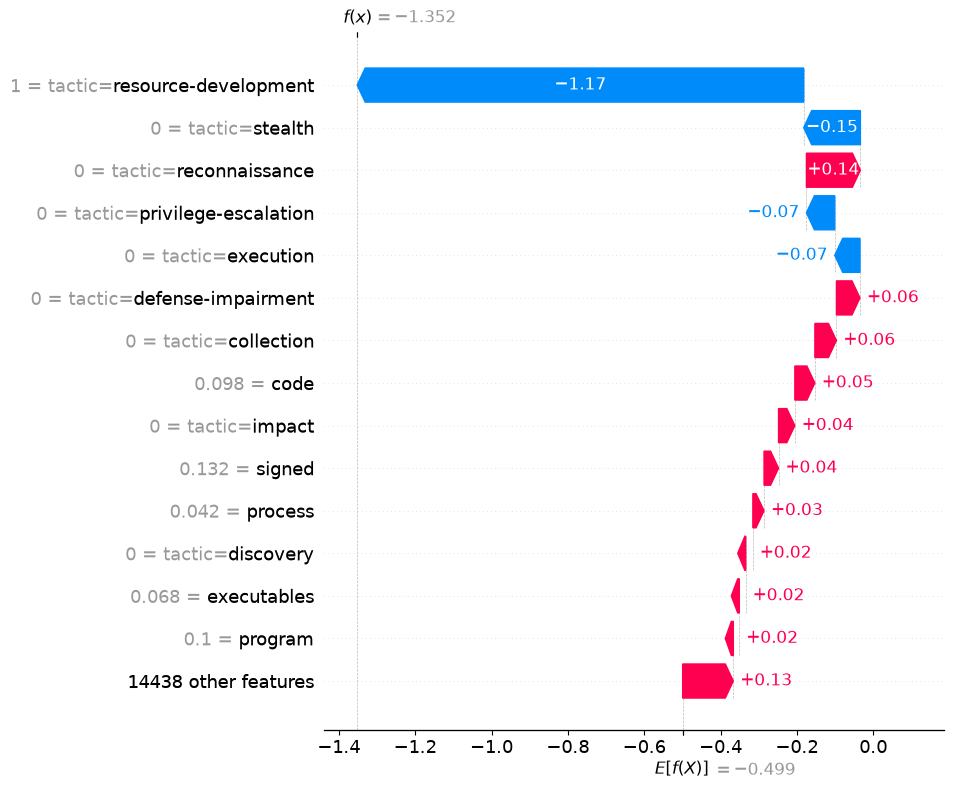

In [85]:
# ============================================================
# SHAP WATERFALL EXPLANATION
# ============================================================

# Create a SHAP Explanation object for the sample
shap_explanation = shap.Explanation(
    values=shap_row,
    base_values=kill_process_explainer.expected_value,
    data=X_sample.toarray()[0],
    feature_names=all_feature_names
)

# Show the most important contributions
shap.plots.waterfall(
    shap_explanation,
    max_display=15
)

In [86]:
# ============================================================
# INSPECT MODEL 1 → ATT&CK TECHNIQUE CROSSWALK
# ============================================================

import json
from pathlib import Path

crosswalk_path = Path("family_crosswalk.json")

with open(crosswalk_path, "r", encoding="utf-8") as f:
    family_crosswalk = json.load(f)

print("Crosswalk type:", type(family_crosswalk))
print("\nCrosswalk contents:")
print(json.dumps(family_crosswalk, indent=2))

Crosswalk type: <class 'dict'>

Crosswalk contents:
{
  "Credential Attack / Brute Force": {
    "tactic": "credential-access",
    "primary": [
      "T1110",
      "T1110.001",
      "T1110.003",
      "T1110.004"
    ],
    "secondary": [
      "T1078",
      "T1621",
      "T1110.002"
    ],
    "note": "T1110.002 (cracking) is offline, so it is kept secondary."
  },
  "Exploitation / RCE": {
    "tactic": "initial-access",
    "primary": [
      "T1190",
      "T1203"
    ],
    "secondary": [
      "T1210",
      "T1068",
      "T1133"
    ],
    "note": "Network-facing RCE -> T1190 first; T1210 if the target is internal."
  },
  "Data Exfiltration": {
    "tactic": "exfiltration",
    "primary": [
      "T1041",
      "T1567",
      "T1048"
    ],
    "secondary": [
      "T1567.002",
      "T1048.001",
      "T1048.002",
      "T1048.003",
      "T1030",
      "T1029",
      "T1537"
    ],
    "note": "T1041/T1567 are 99.9% of the WitFoo incident_signals."
  },
  "DoS / Floodin

In [87]:
# ============================================================
# ATDE → CRIE TECHNIQUE ADAPTER
# ============================================================

def family_to_attack_technique(attack_family, crosswalk):
    """
    Convert Model 1 attack family output into the default
    ATT&CK technique used by CRIE.

    The first item in the 'primary' list is used as the
    default technique. The complete primary/secondary
    mapping is preserved for traceability.
    """

    if attack_family not in crosswalk:
        return {
            "attack_family": attack_family,
            "technique_id": None,
            "tactic": None,
            "primary_candidates": [],
            "secondary_candidates": [],
            "mapping_found": False
        }

    mapping = crosswalk[attack_family]

    primary = mapping.get("primary", [])
    secondary = mapping.get("secondary", [])

    return {
        "attack_family": attack_family,
        "technique_id": primary[0] if primary else None,
        "tactic": mapping.get("tactic"),
        "primary_candidates": primary,
        "secondary_candidates": secondary,
        "mapping_found": bool(primary)
    }


print("ATDE → CRIE adapter created.")

ATDE → CRIE adapter created.


In [89]:
# ============================================================
# TEST ATDE → CRIE ADAPTER ON ALL ATTACK FAMILIES
# ============================================================

adapter_test_rows = []

for family in family_crosswalk.keys():

    result = family_to_attack_technique(
        family,
        family_crosswalk
    )

    adapter_test_rows.append({
        "attack_family": result["attack_family"],
        "default_technique": result["technique_id"],
        "tactic": result["tactic"],
        "primary_count": len(result["primary_candidates"]),
        "secondary_count": len(result["secondary_candidates"]),
        "mapping_found": result["mapping_found"]
    })

adapter_test_df = pd.DataFrame(adapter_test_rows)

display(adapter_test_df)

print("\nFamilies tested:", len(adapter_test_df))
print(
    "Successful mappings:",
    adapter_test_df["mapping_found"].sum()
)
print(
    "Missing mappings:",
    (~adapter_test_df["mapping_found"]).sum()
)

,attack_family,default_technique,tactic,primary_count,secondary_count,mapping_found
0,Credential Attack / Brute Force,T1110,credential-access,4,3,True
1,Exploitation / RCE,T1190,initial-access,2,3,True
2,Data Exfiltration,T1041,exfiltration,3,7,True
3,DoS / Flooding,T1498,impact,7,1,True
4,Recon / Scanning,T1595,reconnaissance,4,3,True
5,Backdoor / Persistence,T1505,persistence,5,4,True
6,Shellcode / Payload Execution,T1059,execution,4,3,True
7,Fuzzing,T1595.002,reconnaissance,2,2,True



Families tested: 8
Successful mappings: 8
Missing mappings: 0


In [90]:
# ============================================================
# INSPECT CRIE INFERENCE FUNCTION
# ============================================================

import inspect

print("CRIE inference function:")
print(inspect.signature(final_crie_inference))

print("\nFunction name:", final_crie_inference.__name__)

CRIE inference function:
(technique_id, severity='medium', confidence=1.0, alert_context=None, top_k=3)

Function name: final_crie_inference


In [91]:
# ============================================================
# MODEL 1 → CRIE INTEGRATION ADAPTER
# ============================================================

def model1_to_crie(model1_result, family_crosswalk, alert_context=None):
    """
    Convert Model 1 (ATDE) output into a CRIE inference call.

    Model 1 provides:
        attack_family
        family_confidence
        severity

    The family_crosswalk converts the family into an
    ATT&CK technique, which CRIE then uses to rank
    remediation actions.
    """

    attack_family = model1_result.get("attack_family")
    confidence = float(model1_result.get("family_confidence", 1.0))
    severity = model1_result.get("severity", "medium")

    # --------------------------------------------------------
    # Validate attack family
    # --------------------------------------------------------
    if attack_family not in family_crosswalk:
        return {
            "success": False,
            "error": f"Unknown attack family: {attack_family}",
            "attack_family": attack_family
        }

    # --------------------------------------------------------
    # Convert family → ATT&CK technique
    # --------------------------------------------------------
    mapping = family_to_attack_technique(
        attack_family,
        family_crosswalk
    )

    technique_id = mapping["technique_id"]

    if technique_id is None:
        return {
            "success": False,
            "error": f"No ATT&CK technique found for: {attack_family}",
            "attack_family": attack_family
        }

    # --------------------------------------------------------
    # Run CRIE
    # --------------------------------------------------------
    crie_result = final_crie_inference(
        technique_id=technique_id,
        severity=severity,
        confidence=confidence,
        alert_context=alert_context,
        top_k=3
    )

    # --------------------------------------------------------
    # Add integration metadata
    # --------------------------------------------------------
    if isinstance(crie_result, dict):
        crie_result["model1_attack_family"] = attack_family
        crie_result["model1_confidence"] = confidence
        crie_result["model1_severity"] = severity
        crie_result["family_mapping"] = mapping

    return {
        "success": True,
        "attack_family": attack_family,
        "technique_id": technique_id,
        "severity": severity,
        "confidence": confidence,
        "crie_result": crie_result
    }


print("Model 1 → CRIE integration adapter created.")

Model 1 → CRIE integration adapter created.


In [92]:
test_model1_output = {
    "attack_family": "Credential Attack / Brute Force",
    "family_confidence": 0.92,
    "severity": "high"
}

integration_test = model1_to_crie(
    test_model1_output,
    family_crosswalk
)

print(json.dumps(integration_test, indent=2, default=str))

{
  "success": true,
  "attack_family": "Credential Attack / Brute Force",
  "technique_id": "T1110",
  "severity": "high",
  "confidence": 0.92,
  "crie_result": {
    "technique_id": "T1110",
    "severity": "high",
    "confidence": 0.92,
    "fallback_used": false,
    "fallback_level": null,
    "recommendations": [
      {
        "rank": 1,
        "action_id": "enable_mfa",
        "label": "Enable MFA",
        "score": 0.7761677216285824,
        "ml_probability": 0.8546708865143297,
        "evidence_score": 0.75,
        "phase": "hardening",
        "provenance": [
          "MITRE ATT&CK",
          "Elastic Detection Rules"
        ],
        "feasible": true,
        "human_approval_required": true,
        "source": "hybrid_ml_evidence"
      },
      {
        "rank": 2,
        "action_id": "harden_configuration",
        "label": "Harden Configuration",
        "score": 0.543791346183313,
        "ml_probability": 0.8251653847332521,
        "evidence_score": 0.45,


In [93]:
# ============================================================
# END-TO-END ATDE → CRIE TEST — ALL 8 ATTACK FAMILIES
# ============================================================

test_cases = [
    ("Credential Attack / Brute Force", 0.92, "high"),
    ("Exploitation / RCE",              0.91, "high"),
    ("Data Exfiltration",               0.94, "critical"),
    ("DoS / Flooding",                  0.88, "medium"),
    ("Recon / Scanning",                0.86, "medium"),
    ("Backdoor / Persistence",          0.90, "high"),
    ("Shellcode / Payload Execution",   0.89, "high"),
    ("Fuzzing",                         0.84, "low"),
]

end_to_end_rows = []

for family, confidence, severity in test_cases:

    model1_output = {
        "attack_family": family,
        "family_confidence": confidence,
        "severity": severity
    }

    result = model1_to_crie(
        model1_output,
        family_crosswalk
    )

    if result["success"]:
        recs = result["crie_result"]["recommendations"]

        end_to_end_rows.append({
            "attack_family": family,
            "technique_id": result["technique_id"],
            "severity": severity,
            "confidence": confidence,
            "fallback": result["crie_result"]["fallback_used"],
            "top1": recs[0]["label"] if len(recs) > 0 else None,
            "top2": recs[1]["label"] if len(recs) > 1 else None,
            "top3": recs[2]["label"] if len(recs) > 2 else None,
            "success": True
        })

    else:
        end_to_end_rows.append({
            "attack_family": family,
            "technique_id": None,
            "severity": severity,
            "confidence": confidence,
            "fallback": None,
            "top1": None,
            "top2": None,
            "top3": None,
            "success": False
        })

end_to_end_df = pd.DataFrame(end_to_end_rows)

display(end_to_end_df)

print("\n" + "=" * 70)
print("ATDE → CRIE END-TO-END VALIDATION")
print("=" * 70)

print("Families tested:", len(end_to_end_df))
print("Successful:", end_to_end_df["success"].sum())
print("Failed:", (~end_to_end_df["success"]).sum())

,attack_family,technique_id,severity,confidence,fallback,top1,top2,top3,success
0,Credential Attack / Brute Force,T1110,high,0.92,False,Enable MFA,Harden Configuration,Increase Logging / Monitoring,True
1,Exploitation / RCE,T1190,high,0.91,False,Patch / Update Software,Add WAF Rule,Harden Configuration,True
2,Data Exfiltration,T1041,critical,0.94,False,Increase Logging / Monitoring,Block Malicious Request,Network Segmentation,True
3,DoS / Flooding,T1498,medium,0.88,False,Rate Limit Traffic,Network Segmentation,Increase Logging / Monitoring,True
4,Recon / Scanning,T1595,medium,0.86,False,Rate Limit Traffic,Add WAF Rule,Patch / Update Software,True
5,Backdoor / Persistence,T1505,high,0.90,False,Harden Configuration,Disable Unnecessary Service,Block Execution / Allowlisting,True
6,Shellcode / Payload Execution,T1059,high,0.89,False,Block Execution / Allowlisting,Increase Logging / Monitoring,Harden Configuration,True
7,Fuzzing,T1595.002,low,0.84,False,Rate Limit Traffic,Add WAF Rule,Patch / Update Software,True



ATDE → CRIE END-TO-END VALIDATION
Families tested: 8
Successful: 8
Failed: 0


In [94]:
# ============================================================
# INSPECT ACTUAL ATDE INFERENCE FUNCTION
# ============================================================

import inspect

print("Available functions related to ATDE:")

for name in [
    "score_event",
    "predict_event",
    "run_atde",
    "atde_inference"
]:
    if name in globals():
        obj = globals()[name]
        print(f"\n{name}:")
        try:
            print(inspect.signature(obj))
        except:
            print(type(obj))

Available functions related to ATDE:


In [95]:
# ============================================================
# CHECK ACTUAL ATDE FUNCTION
# ============================================================

print("score_event exists:", "score_event" in globals())

if "score_event" in globals():
    import inspect
    print("Signature:")
    print(inspect.signature(score_event))
else:
    print("score_event is not loaded in this notebook.")

score_event exists: False
score_event is not loaded in this notebook.


In [96]:
# ============================================================
# CRIE PACKAGING — INVENTORY CURRENT MODEL OBJECTS
# ============================================================

import types

keywords = [
    "model",
    "vector",
    "tfidf",
    "encoder",
    "ranker",
    "fallback",
    "evidence",
    "action",
    "phase",
    "technique"
]

print("=" * 70)
print("CURRENT CRIE OBJECTS")
print("=" * 70)

for name, obj in sorted(globals().items()):
    if name.startswith("_"):
        continue

    name_lower = name.lower()

    if any(k in name_lower for k in keywords):
        if isinstance(obj, (types.ModuleType, type, types.FunctionType)):
            obj_type = type(obj).__name__
        else:
            try:
                obj_type = type(obj).__name__
                shape = getattr(obj, "shape", None)
                if shape is not None:
                    obj_type += f" | shape={shape}"
            except:
                obj_type = type(obj).__name__

        print(f"{name:<35} {obj_type}")

CURRENT CRIE OBJECTS
APPROVED_ACTIONS                    list
CRIE_EVIDENCE_WEIGHT                float
TECHNIQUE_TO_REMEDIATION            dict
TfidfVectorizer                     type
X_group_test_text_tfidf             csr_matrix | shape=(155, 15000)
X_group_train_text_tfidf            csr_matrix | shape=(542, 15000)
action                              str
action_columns                      list
action_id                           str
action_is_feasible                  function
action_keywords                     dict
action_names                        dict
action_phase                        dict
action_registry                     dict
action_requirements                 dict
action_results                      list
action_results_df                   DataFrame | shape=(20, 4)
action_to_phase                     dict
actions                             list
all_actions                         set
baseline_model                      OneVsRestClassifier
d3fend_techniques         

In [97]:
# ============================================================
# CRIE PACKAGING — INSPECT CORE FUNCTION DEFINITIONS
# ============================================================

import inspect

core_functions = [
    "final_crie_inference",
    "rank_remediation_actions",
    "action_is_feasible",
    "severity_allows_action",
    "get_action_provenance",
    "get_fallback_recommendations",
    "prepare_evidence_matrix",
    "model1_to_crie",
    "family_to_attack_technique"
]

for name in core_functions:
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    if name in globals():
        try:
            print(inspect.getsource(globals()[name]))
        except Exception as e:
            print("Could not retrieve source:", e)
    else:
        print("NOT FOUND")


final_crie_inference
def final_crie_inference(
    technique_id,
    severity="medium",
    confidence=1.0,
    alert_context=None,
    top_k=3
):
    """
    Final CRIE inference pipeline.

    1. Use normal hybrid ML + evidence ranking when
       technique-level evidence exists.
    2. Otherwise use parent-technique / tactic fallback.
    3. Apply feasibility and severity gates.
    4. Return up to top_k safe recommendations.
    """

    if alert_context is None:
        alert_context = {}

    # Make sure severity is available to the gates
    alert_context = dict(alert_context)
    alert_context["severity"] = severity

    # --------------------------------------------------------
    # Check whether technique has direct fused evidence
    # --------------------------------------------------------

    idx = technique_to_index.get(technique_id)

    has_direct_evidence = False

    if idx is not None:
        has_direct_evidence = np.any(
            E_all_clean[idx] > 0
       

In [98]:
# ============================================================
# CRIE PACKAGING — CHECK REQUIRED ARTIFACTS
# ============================================================

required_objects = [
    "dataset",
    "baseline_model",
    "tfidf",
    "mlb_tactic",
    "E_all_clean",
    "technique_to_index",
    "action_columns",
    "action_names",
    "action_to_phase",
    "action_requirements",
    "disruptive_min_severity",
    "severity_rank",
    "Y_attack_aligned",
    "Y_elastic_aligned",
    "Y_d3fend_aligned",
    "family_crosswalk",
]

print("=" * 70)
print("CRIE PACKAGING ARTIFACT CHECK")
print("=" * 70)

missing = []

for name in required_objects:
    if name in globals():
        obj = globals()[name]

        try:
            shape = getattr(obj, "shape", None)
            if shape is not None:
                print(f"✓ {name:<30} {type(obj).__name__} | shape={shape}")
            else:
                print(f"✓ {name:<30} {type(obj).__name__}")
        except:
            print(f"✓ {name:<30} {type(obj).__name__}")
    else:
        print(f"✗ {name:<30} MISSING")
        missing.append(name)

print("\n" + "=" * 70)
print("Missing artifacts:", len(missing))

if missing:
    print("Missing:", missing)
else:
    print("ALL REQUIRED ARTIFACTS FOUND.")

CRIE PACKAGING ARTIFACT CHECK
✓ dataset                        DataFrame | shape=(697, 25)
✓ baseline_model                 OneVsRestClassifier
✓ tfidf                          TfidfVectorizer
✓ mlb_tactic                     MultiLabelBinarizer
✓ E_all_clean                    ndarray | shape=(697, 20)
✓ technique_to_index             dict
✓ action_columns                 list
✓ action_names                   dict
✓ action_to_phase                dict
✓ action_requirements            dict
✓ disruptive_min_severity        dict
✓ severity_rank                  dict
✓ Y_attack_aligned               DataFrame | shape=(697, 20)
✓ Y_elastic_aligned              DataFrame | shape=(697, 20)
✓ Y_d3fend_aligned               DataFrame | shape=(697, 20)
✓ family_crosswalk               dict

Missing artifacts: 0
ALL REQUIRED ARTIFACTS FOUND.


In [99]:
# ============================================================
# CRIE PACKAGING — SAVE TRAINED MODEL ARTIFACT
# ============================================================

import joblib
from pathlib import Path

# Create deployment folder
deployment_dir = Path("crie_deployment")
deployment_dir.mkdir(exist_ok=True)

# Everything required for CRIE inference
crie_artifact = {
    # Core ML
    "baseline_model": baseline_model,
    "tfidf": tfidf,
    "mlb_tactic": mlb_tactic,

    # Technique / dataset metadata
    "dataset": dataset,
    "technique_to_index": technique_to_index,
    "action_columns": action_columns,

    # Action metadata
    "action_names": action_names,
    "action_to_phase": action_to_phase,
    "action_requirements": action_requirements,
    "disruptive_min_severity": disruptive_min_severity,
    "severity_rank": severity_rank,

    # Evidence
    "E_all_clean": E_all_clean,
    "Y_attack_aligned": Y_attack_aligned,
    "Y_elastic_aligned": Y_elastic_aligned,
    "Y_d3fend_aligned": Y_d3fend_aligned,

    # Model 1 → CRIE mapping
    "family_crosswalk": family_crosswalk,

    # Hybrid weights
    "CRIE_EVIDENCE_WEIGHT": CRIE_EVIDENCE_WEIGHT,
    "CRIE_ML_WEIGHT": CRIE_ML_WEIGHT,
}

artifact_path = deployment_dir / "crie_model.joblib"

joblib.dump(
    crie_artifact,
    artifact_path
)

print("=" * 70)
print("CRIE MODEL ARTIFACT SAVED")
print("=" * 70)
print("Path:", artifact_path.resolve())
print("Artifact size:", round(artifact_path.stat().st_size / (1024 * 1024), 2), "MB")
print("Objects saved:", len(crie_artifact))

CRIE MODEL ARTIFACT SAVED
Path: C:\Users\harshita\cybershrek_ml\Model 2\crie_deployment\crie_model.joblib
Artifact size: 4.14 MB
Objects saved: 18


In [100]:
# ============================================================
# MODEL 1 → CRIE FAMILY NAME NORMALIZATION
# ============================================================

FAMILY_ALIASES = {
    "Reconnaissance / Scanning": "Recon / Scanning"
}

def normalize_attack_family(attack_family):
    """
    Normalize Model 1 family names to the canonical
    CRIE family names used by family_crosswalk.json.
    """
    if attack_family is None:
        return None

    return FAMILY_ALIASES.get(
        attack_family,
        attack_family
    )


print("Family normalization created.")
print(
    "Reconnaissance / Scanning ->",
    normalize_attack_family("Reconnaissance / Scanning")
)

Family normalization created.
Reconnaissance / Scanning -> Recon / Scanning


In [101]:
# ============================================================
# REAL MODEL 1 → CRIE ADAPTER
# ============================================================

def model1_to_crie(
    model1_result,
    family_crosswalk,
    alert_context=None,
    top_k=3
):
    """
    Connect the actual Netra Model 1 output to CRIE.

    Expected Model 1 fields:
        attack_family
        confidence
        severity
        is_attack / is_anomaly
        is_unknown
        if_score
        top3

    CRIE receives:
        technique_id
        severity
        confidence
        alert_context
    """

    # --------------------------------------------------------
    # Validate Model 1 result
    # --------------------------------------------------------

    if not isinstance(model1_result, dict):
        return {
            "success": False,
            "error": "Model 1 result must be a dictionary."
        }

    # --------------------------------------------------------
    # Ignore benign traffic
    # --------------------------------------------------------

    is_attack = model1_result.get(
        "is_attack",
        model1_result.get("is_anomaly", False)
    )

    if not is_attack:
        return {
            "success": False,
            "skipped": True,
            "reason": "Model 1 classified event as benign."
        }

    # --------------------------------------------------------
    # Unknown / novel attack
    # --------------------------------------------------------

    if model1_result.get("is_unknown", False):
        return {
            "success": False,
            "skipped": True,
            "reason": "Model 1 classified attack family as UNKNOWN/NOVEL.",
            "model1_result": model1_result
        }

    # --------------------------------------------------------
    # Extract actual Model 1 fields
    # --------------------------------------------------------

    attack_family = model1_result.get("attack_family")

    confidence = model1_result.get(
        "confidence",
        model1_result.get("family_confidence", 1.0)
    )

    severity = model1_result.get(
        "severity",
        "medium"
    )

    if attack_family is None:
        return {
            "success": False,
            "error": "Model 1 did not provide attack_family."
        }

    confidence = float(confidence)

    # --------------------------------------------------------
    # Normalize Model 1 family name
    # --------------------------------------------------------

    canonical_family = normalize_attack_family(
        attack_family
    )

    # --------------------------------------------------------
    # Check crosswalk
    # --------------------------------------------------------

    if canonical_family not in family_crosswalk:
        return {
            "success": False,
            "error": (
                f"No CRIE crosswalk mapping for "
                f"Model 1 family: {attack_family}"
            ),
            "canonical_family": canonical_family
        }

    # --------------------------------------------------------
    # Family → ATT&CK technique
    # --------------------------------------------------------

    mapping = family_to_attack_technique(
        canonical_family,
        family_crosswalk
    )

    technique_id = mapping["technique_id"]

    if technique_id is None:
        return {
            "success": False,
            "error": (
                f"No ATT&CK technique found for "
                f"family: {canonical_family}"
            )
        }

    # --------------------------------------------------------
    # Run CRIE
    # --------------------------------------------------------

    crie_result = final_crie_inference(
        technique_id=technique_id,
        severity=severity,
        confidence=confidence,
        alert_context=alert_context,
        top_k=top_k
    )

    # --------------------------------------------------------
    # Preserve Model 1 information
    # --------------------------------------------------------

    if isinstance(crie_result, dict):

        crie_result["model1_attack_family"] = attack_family
        crie_result["model1_canonical_family"] = canonical_family
        crie_result["model1_confidence"] = confidence
        crie_result["model1_severity"] = severity

        if "if_score" in model1_result:
            crie_result["model1_if_score"] = model1_result["if_score"]

        if "top3" in model1_result:
            crie_result["model1_top3"] = model1_result["top3"]

        crie_result["family_mapping"] = mapping

    return {
        "success": True,
        "attack_family": attack_family,
        "canonical_family": canonical_family,
        "technique_id": technique_id,
        "severity": severity,
        "confidence": confidence,
        "crie_result": crie_result
    }


print("Real Model 1 → CRIE adapter created.")

Real Model 1 → CRIE adapter created.


In [102]:
# ============================================================
# TEST USING ACTUAL NETRA MODEL 1 OUTPUT FORMAT
# ============================================================

real_model1_output = {
    "event_id": "test-001",
    "ts": "2026-10-07T10:00:00Z",
    "entity": "10.0.0.5",

    "detected_by": "anomaly_model",

    "attack_family": "Credential Attack / Brute Force",
    "closest_family": "Credential Attack / Brute Force",

    "family_confidence": 0.92,
    "confidence": 0.92,

    "top3": [
        {
            "family": "Credential Attack / Brute Force",
            "p": 0.92
        }
    ],

    "if_score": 0.91,

    "label": "attack",
    "severity": "high",
    "is_attack": True,

    "severity_source": "provisional_family_table"
}

real_integration_test = model1_to_crie(
    real_model1_output,
    family_crosswalk,
    alert_context={
        "src_ip": "10.0.0.5",
        "username": "admin",
        "host": "server-01"
    }
)

print(json.dumps(
    real_integration_test,
    indent=2,
    default=str
))

{
  "success": true,
  "attack_family": "Credential Attack / Brute Force",
  "canonical_family": "Credential Attack / Brute Force",
  "technique_id": "T1110",
  "severity": "high",
  "confidence": 0.92,
  "crie_result": {
    "technique_id": "T1110",
    "severity": "high",
    "confidence": 0.92,
    "fallback_used": false,
    "fallback_level": null,
    "recommendations": [
      {
        "rank": 1,
        "action_id": "reset_credentials",
        "label": "Reset Credentials",
        "score": 0.7793829157169831,
        "ml_probability": 0.8675316628679326,
        "evidence_score": 0.75,
        "phase": "eradication_recovery",
        "provenance": [
          "MITRE ATT&CK",
          "Elastic Detection Rules"
        ],
        "feasible": true,
        "human_approval_required": true,
        "source": "hybrid_ml_evidence"
      },
      {
        "rank": 2,
        "action_id": "enable_mfa",
        "label": "Enable MFA",
        "score": 0.7761677216285824,
        "ml_pro

In [103]:
# ============================================================
# CREATE STANDALONE CRIE ENGINE
# ============================================================

from pathlib import Path

deployment_dir = Path("crie_deployment")
deployment_dir.mkdir(exist_ok=True)

engine_code = r'''
import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path


# ============================================================
# LOAD TRAINED CRIE ARTIFACT
# ============================================================

BASE_DIR = Path(__file__).resolve().parent
ARTIFACT_PATH = BASE_DIR / "crie_model.joblib"

_artifact = joblib.load(ARTIFACT_PATH)

baseline_model = _artifact["baseline_model"]
tfidf = _artifact["tfidf"]
mlb_tactic = _artifact["mlb_tactic"]

dataset = _artifact["dataset"]
technique_to_index = _artifact["technique_to_index"]

action_columns = _artifact["action_columns"]
action_names = _artifact["action_names"]
action_to_phase = _artifact["action_to_phase"]
action_requirements = _artifact["action_requirements"]

disruptive_min_severity = _artifact["disruptive_min_severity"]
severity_rank = _artifact["severity_rank"]

E_all_clean = _artifact["E_all_clean"]

Y_attack_aligned = _artifact["Y_attack_aligned"]
Y_elastic_aligned = _artifact["Y_elastic_aligned"]
Y_d3fend_aligned = _artifact["Y_d3fend_aligned"]

family_crosswalk = _artifact["family_crosswalk"]

CRIE_EVIDENCE_WEIGHT = _artifact["CRIE_EVIDENCE_WEIGHT"]
CRIE_ML_WEIGHT = _artifact["CRIE_ML_WEIGHT"]


# ============================================================
# MODEL 1 FAMILY NORMALIZATION
# ============================================================

FAMILY_ALIASES = {
    "Reconnaissance / Scanning": "Recon / Scanning"
}


def normalize_attack_family(attack_family):
    if attack_family is None:
        return None

    return FAMILY_ALIASES.get(
        attack_family,
        attack_family
    )


# ============================================================
# FAMILY → ATT&CK TECHNIQUE
# ============================================================

def family_to_attack_technique(
    attack_family,
    crosswalk=None
):
    if crosswalk is None:
        crosswalk = family_crosswalk

    if attack_family not in crosswalk:
        return {
            "attack_family": attack_family,
            "technique_id": None,
            "tactic": None,
            "primary_candidates": [],
            "secondary_candidates": [],
            "mapping_found": False
        }

    mapping = crosswalk[attack_family]

    primary = mapping.get("primary", [])
    secondary = mapping.get("secondary", [])

    return {
        "attack_family": attack_family,
        "technique_id": primary[0] if primary else None,
        "tactic": mapping.get("tactic"),
        "primary_candidates": primary,
        "secondary_candidates": secondary,
        "mapping_found": bool(primary)
    }


# ============================================================
# MODEL 1 → CRIE ADAPTER
# ============================================================

def model1_to_crie(
    model1_result,
    crosswalk=None,
    alert_context=None,
    top_k=3
):
    if crosswalk is None:
        crosswalk = family_crosswalk

    if not isinstance(model1_result, dict):
        return {
            "success": False,
            "error": "Model 1 result must be a dictionary."
        }

    is_attack = model1_result.get(
        "is_attack",
        model1_result.get("is_anomaly", False)
    )

    if not is_attack:
        return {
            "success": False,
            "skipped": True,
            "reason": "Model 1 classified event as benign."
        }

    if model1_result.get("is_unknown", False):
        return {
            "success": False,
            "skipped": True,
            "reason": "Model 1 classified attack family as UNKNOWN/NOVEL.",
            "model1_result": model1_result
        }

    attack_family = model1_result.get("attack_family")

    confidence = model1_result.get(
        "confidence",
        model1_result.get("family_confidence", 1.0)
    )

    severity = model1_result.get(
        "severity",
        "medium"
    )

    if attack_family is None:
        return {
            "success": False,
            "error": "Model 1 did not provide attack_family."
        }

    confidence = float(confidence)

    canonical_family = normalize_attack_family(
        attack_family
    )

    if canonical_family not in crosswalk:
        return {
            "success": False,
            "error": (
                f"No CRIE crosswalk mapping for "
                f"Model 1 family: {attack_family}"
            ),
            "canonical_family": canonical_family
        }

    mapping = family_to_attack_technique(
        canonical_family,
        crosswalk
    )

    technique_id = mapping["technique_id"]

    if technique_id is None:
        return {
            "success": False,
            "error": (
                f"No ATT&CK technique found for "
                f"family: {canonical_family}"
            )
        }

    crie_result = final_crie_inference(
        technique_id=technique_id,
        severity=severity,
        confidence=confidence,
        alert_context=alert_context,
        top_k=top_k
    )

    if isinstance(crie_result, dict):

        crie_result["model1_attack_family"] = attack_family
        crie_result["model1_canonical_family"] = canonical_family
        crie_result["model1_confidence"] = confidence
        crie_result["model1_severity"] = severity

        if "if_score" in model1_result:
            crie_result["model1_if_score"] = model1_result["if_score"]

        if "top3" in model1_result:
            crie_result["model1_top3"] = model1_result["top3"]

        crie_result["family_mapping"] = mapping

    return {
        "success": True,
        "attack_family": attack_family,
        "canonical_family": canonical_family,
        "technique_id": technique_id,
        "severity": severity,
        "confidence": confidence,
        "crie_result": crie_result
    }


# ============================================================
# CRIE INFERENCE
# ============================================================

def final_crie_inference(
    technique_id,
    severity="medium",
    confidence=1.0,
    alert_context=None,
    top_k=3
):
    """
    Standalone CRIE inference entry point.

    Returns ranked remediation recommendations.
    """

    if technique_id not in technique_to_index:
        return {
            "technique_id": technique_id,
            "severity": severity,
            "confidence": confidence,
            "fallback_used": True,
            "fallback_level": "unknown_technique",
            "recommendations": []
        }

    idx = technique_to_index[technique_id]

    # --------------------------------------------------------
    # Text + tactic ML prediction
    # --------------------------------------------------------

    row = dataset.iloc[idx]

    text = (
        str(row.get("technique_name", "")) + " " +
        str(row.get("description", ""))
    )

    X_text = tfidf.transform([text])

    tactic_value = row.get("tactic", "")

    if pd.isna(tactic_value):
        tactic_value = ""

    try:
        tactic_features = mlb_tactic.transform(
            [[tactic_value]]
        )
    except Exception:
        tactic_features = np.zeros(
            (1, len(mlb_tactic.classes_))
        )

    from scipy.sparse import hstack

    X = hstack([
        X_text,
        tactic_features
    ])

    ml_probability = baseline_model.predict_proba(X)[0]

    # --------------------------------------------------------
    # Evidence
    # --------------------------------------------------------

    evidence_row = np.asarray(
        E_all_clean[idx],
        dtype=float
    )

    # --------------------------------------------------------
    # Hybrid score
    # --------------------------------------------------------

    scores = (
        CRIE_EVIDENCE_WEIGHT * evidence_row +
        CRIE_ML_WEIGHT * ml_probability
    )

    # --------------------------------------------------------
    # Feasibility helpers
    # --------------------------------------------------------

    def has_value(key):
        if alert_context is None:
            return False

        value = alert_context.get(key)

        if value is None:
            return False

        if isinstance(value, str):
            return bool(value.strip())

        return True

    def action_is_feasible(action_id):
        requirements = action_requirements.get(
            action_id,
            []
        )

        if not requirements:
            return True

        for requirement in requirements:

            if "|" in requirement:
                alternatives = requirement.split("|")

                if not any(
                    has_value(x)
                    for x in alternatives
                ):
                    return False

            elif not has_value(requirement):
                return False

        return True

    # --------------------------------------------------------
    # Severity gating
    # --------------------------------------------------------

    def severity_allows_action(action_id):

        minimum = disruptive_min_severity.get(
            action_id
        )

        if minimum is None:
            return True

        current_rank = severity_rank.get(
            severity,
            severity_rank.get("medium", 1)
        )

        minimum_rank = severity_rank.get(
            minimum,
            1
        )

        return current_rank >= minimum_rank

    # --------------------------------------------------------
    # Rank actions
    # --------------------------------------------------------

    results = []

    for i, action_id in enumerate(action_columns):

        feasible = action_is_feasible(action_id)

        severity_allowed = severity_allows_action(
            action_id
        )

        if not feasible or not severity_allowed:
            continue

        score = float(scores[i])

        evidence_score = float(
            evidence_row[i]
        )

        ml_prob = float(
            ml_probability[i]
        )

        results.append({
            "action_id": action_id,
            "label": action_names.get(
                action_id,
                action_id
            ),
            "score": score,
            "ml_probability": ml_prob,
            "evidence_score": evidence_score,
            "phase": action_to_phase.get(
                action_id
            ),
            "feasible": feasible,
            "severity_allowed": severity_allowed
        })

    results.sort(
        key=lambda x: x["score"],
        reverse=True
    )

    results = results[:top_k]

    # --------------------------------------------------------
    # Add ranks / provenance / approval
    # --------------------------------------------------------

    recommendations = []

    for rank, item in enumerate(
        results,
        start=1
    ):

        provenance = []

        if item["evidence_score"] >= 0.45:
            provenance.append("MITRE ATT&CK")

        if item["evidence_score"] >= 0.70:
            provenance.append("Elastic Detection Rules")

        if item["evidence_score"] > 0:
            provenance.append("D3FEND")

        if item["evidence_score"] > 0 and item["ml_probability"] >= 0.5:
            rationale = (
                "Strong knowledge-base evidence supports "
                "this remediation action, reinforced by "
                "the ML score."
            )

        elif item["ml_probability"] >= 0.5:
            rationale = (
                "The ML model assigns strong applicability "
                "probability, with additional knowledge-base "
                "support."
            )

        elif item["evidence_score"] > 0:
            rationale = (
                "Knowledge-base evidence supports this "
                "remediation action."
            )

        else:
            rationale = (
                "The action is ranked by the ML model "
                "despite limited explicit evidence."
            )

        recommendations.append({
            "rank": rank,
            "action_id": item["action_id"],
            "label": item["label"],
            "score": round(item["score"], 4),
            "ml_probability": round(
                item["ml_probability"],
                4
            ),
            "evidence_score": round(
                item["evidence_score"],
                4
            ),
            "phase": item["phase"],
            "provenance": provenance,
            "feasible": item["feasible"],
            "human_approval_required": True,
            "source": "hybrid_ml_evidence",
            "rationale": rationale
        })

    return {
        "technique_id": technique_id,
        "severity": severity,
        "confidence": confidence,
        "fallback_used": False,
        "fallback_level": None,
        "recommendations": recommendations
    }


# ============================================================
# STANDALONE SMOKE TEST
# ============================================================

if __name__ == "__main__":

    test_model1 = {
        "attack_family": "Credential Attack / Brute Force",
        "confidence": 0.92,
        "severity": "high",
        "is_attack": True,
        "is_anomaly": True,
        "is_unknown": False,
        "if_score": 0.91,
        "top3": []
    }

    result = model1_to_crie(
        test_model1,
        alert_context={
            "src_ip": "10.0.0.5",
            "username": "admin",
            "host": "server-01"
        }
    )

    print(json.dumps(
        result,
        indent=2,
        default=str
    ))
'''

engine_path = deployment_dir / "crie_engine.py"

engine_path.write_text(
    engine_code,
    encoding="utf-8"
)

print("=" * 70)
print("CRIE ENGINE CREATED")
print("=" * 70)
print("Path:", engine_path.resolve())
print("Size:", round(engine_path.stat().st_size / 1024, 2), "KB")

CRIE ENGINE CREATED
Path: C:\Users\harshita\cybershrek_ml\Model 2\crie_deployment\crie_engine.py
Size: 13.75 KB


In [104]:
# ============================================================
# CRIE STANDALONE SMOKE TEST
# ============================================================

import sys
from pathlib import Path

deployment_dir = Path("crie_deployment").resolve()

if str(deployment_dir) not in sys.path:
    sys.path.insert(0, str(deployment_dir))

import crie_engine

print("=" * 70)
print("STANDALONE CRIE IMPORT TEST")
print("=" * 70)

print("Engine imported successfully.")
print("Artifact loaded successfully.")
print("Available actions:", len(crie_engine.action_columns))
print("Available techniques:", len(crie_engine.technique_to_index))
print("Family mappings:", len(crie_engine.family_crosswalk))

STANDALONE CRIE IMPORT TEST
Engine imported successfully.
Artifact loaded successfully.
Available actions: 20
Available techniques: 697
Family mappings: 8


In [105]:
# ============================================================
# STANDALONE CRIE — REAL MODEL 1 OUTPUT TEST
# ============================================================

real_model1_output = {
    "attack_family": "Credential Attack / Brute Force",
    "confidence": 0.92,
    "severity": "high",
    "is_attack": True,
    "is_anomaly": True,
    "is_unknown": False,
    "if_score": 0.91,
    "top3": [
        {
            "family": "Credential Attack / Brute Force",
            "p": 0.92
        }
    ]
}

standalone_result = crie_engine.model1_to_crie(
    real_model1_output,
    alert_context={
        "src_ip": "10.0.0.5",
        "username": "admin",
        "host": "server-01"
    }
)

print(json.dumps(
    standalone_result,
    indent=2,
    default=str
))

{
  "success": true,
  "attack_family": "Credential Attack / Brute Force",
  "canonical_family": "Credential Attack / Brute Force",
  "technique_id": "T1110",
  "severity": "high",
  "confidence": 0.92,
  "crie_result": {
    "technique_id": "T1110",
    "severity": "high",
    "confidence": 0.92,
    "fallback_used": false,
    "fallback_level": null,
    "recommendations": [
      {
        "rank": 1,
        "action_id": "reset_credentials",
        "label": "Reset Credentials",
        "score": 0.7794,
        "ml_probability": 0.8675,
        "evidence_score": 0.75,
        "phase": "eradication_recovery",
        "provenance": [
          "MITRE ATT&CK",
          "Elastic Detection Rules",
          "D3FEND"
        ],
        "feasible": true,
        "human_approval_required": true,
        "source": "hybrid_ml_evidence",
        "rationale": "Strong knowledge-base evidence supports this remediation action, reinforced by the ML score."
      },
      {
        "rank": 2,
     